In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
from tqdm import tqdm
import re

In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

# =====================================================================
# 1. DATASET CLASS
# =====================================================================

TEST_CENTER = 2
VAL_CENTER = 1

class Camelyon17Dataset(Dataset):
    def __init__(self, metadata_df, patches_dir, transform=None):
        """
        Args:
            metadata_df: DataFrame with columns [patient, node, x_coord, y_coord, tumor, center]
            patches_dir: Path to patches directory
            transform: Image transformations
        """
        self.metadata = metadata_df.reset_index(drop=True)
        self.patches_dir = patches_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        
        # Construct image path
        patient = str(row['patient'])
        if len(patient) == 1:
            patient = '00'+patient
        elif len(patient) == 2:
            patient = '0'+patient
            
        node = row['node']
        x = row['x_coord']
        y = row['y_coord']
        
        img_path = os.path.join(
            self.patches_dir,
            f'patient_{patient}_node_{node}',
            f'patch_patient_{patient}_node_{node}_x_{x}_y_{y}.png'
        )
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['tumor'], dtype=torch.long)
        
        return image, label

# =====================================================================
# 2. MODEL ARCHITECTURE
# =====================================================================

class Camelyon17CNN(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super(Camelyon17CNN, self).__init__()
        
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        
        if pretrained:
            self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        else:
            self.backbone = efficientnet_b0(weights=None)
        
        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Get feature dimension
        self.feature_dim = self.backbone.classifier[1].in_features
        
        # Remove final classifier
        self.backbone.classifier = nn.Identity()
        
        # Feature extractor with regularization
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(self.feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
        )
        
        # Output layer (renamed to fc2 for compatibility with score feature code)
        self.fc2 = nn.Linear(256, 1)
    
    def get_features(self, x):
        """Extract features before final classification layer"""
        with torch.no_grad():
            x = self.backbone(x)
        x = self.classifier(x)
        return x
    
    def forward(self, x):
        features = self.get_features(x)
        x = self.fc2(features)
        return x

# =====================================================================
# 3. TRAINING FUNCTIONS
# =====================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.backbone.eval()
    model.classifier.train()
    model.fc2.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(train_loader, desc='Training'):
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validation'):
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# =====================================================================
# 4. SCORE FEATURE DATASET
# =====================================================================

class ScoreFeatureDataset(Dataset):
    def __init__(self, cnn_scores, features, target_decoy_scores, labels):
        self.cnn_scores = cnn_scores
        self.features = features
        self.target_decoy_scores = target_decoy_scores
        self.labels = labels
        
    def __len__(self):
        return len(self.cnn_scores)
    
    def __getitem__(self, idx):
        return (
            self.cnn_scores[idx],
            self.features[idx],
            self.target_decoy_scores[idx],
            self.labels[idx]
        )

def collect_negative_scores(model, dataset, device='cuda'):
    """Collect scores for negative (non-tumor) samples"""
    negative_scores = []
    
    model.eval()
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Collecting negative scores'):
            images = images.to(device)
            labels = labels.to(device)
            
            features = model.get_features(images)
            scores = model.fc2(features)
            
            # Get scores for negative samples (tumor=0)
            neg_mask = labels == 0
            if neg_mask.sum() > 0:
                neg_scores = scores[neg_mask].cpu()
                negative_scores.append(neg_scores)
    
    if negative_scores:
        negative_scores = torch.cat(negative_scores).numpy().flatten()
        print(f"Collected {len(negative_scores)} negative scores")
    else:
        negative_scores = np.array([])
        print("No negative scores collected")
    return negative_scores

def create_score_feature_dataset(dataset, cnn_model, negative_scores_pool, device='cuda'):
    """Create dataset with CNN scores, features, and target-decoy scores"""
    cnn_scores_list = []
    features_list = []
    target_decoy_list = []
    labels_list = []
    
    cnn_model.eval()
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Creating score feature dataset'):
            images = images.to(device)
            
            features = cnn_model.get_features(images)
            scores = cnn_model.fc2(features)
            
            scores_cpu = scores.cpu()
            features_cpu = features.cpu()
            
            # Create target-decoy scores
            target_decoy_scores = scores_cpu.clone()
            
            for i, label in enumerate(labels):
                if label.item() == 1 and len(negative_scores_pool) > 0:
                    # For positive samples, replace with random negative score
                    random_neg_score = np.random.choice(negative_scores_pool)
                    target_decoy_scores[i] = torch.tensor(
                        random_neg_score,
                        dtype=target_decoy_scores.dtype
                    )
            
            cnn_scores_list.append(scores_cpu)
            features_list.append(features_cpu)
            target_decoy_list.append(target_decoy_scores)
            labels_list.append(labels)
    
    all_cnn_scores = torch.cat(cnn_scores_list)
    all_features = torch.cat(features_list)
    all_target_decoy = torch.cat(target_decoy_list)
    all_labels = torch.cat(labels_list)
    
    return ScoreFeatureDataset(all_cnn_scores, all_features, all_target_decoy, all_labels)

# =====================================================================
# 5. MAIN PIPELINE
# =====================================================================

def main():
    # Configuration
    METADATA_PATH = '/kaggle/input/camelyon17/metadata.csv'
    PATCHES_DIR = '/kaggle/input/camelyon17/patches'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    LEARNING_RATE = 5e-5
    
    print("="*70)
    print("CAMELYON17 CLASSIFICATION PIPELINE")
    print("="*70)
    print(f"Device: {DEVICE}")
    
    # Load metadata
    print("\n1. Loading metadata...")
    metadata = pd.read_csv(METADATA_PATH)
    print(f"Total samples: {len(metadata)}")
    print(f"\nClass distribution:")
    print(metadata['tumor'].value_counts())
    print(f"\nCenter distribution:")
    print(metadata['center'].value_counts().sort_index())
    
    # Split by center
    print("\n2. Splitting data by center...")
    train_df = metadata[metadata['center'].isin([0, 3, 4])].copy()
    test_df = metadata[metadata['center'].isin([1, 2])].copy()
    
    unique_patients = train_df['patient'].unique()
    np.random.seed(seed)
    np.random.shuffle(unique_patients)
    
    val_size = int(len(unique_patients) * 0.2)
    val_patients = unique_patients[:val_size]
    train_patients = unique_patients[val_size:]
    val_df = train_df[train_df['patient'].isin(val_patients)].copy()
    train_df = train_df[train_df['patient'].isin(train_patients)].copy()
    
    
    print(f"Train: {len(train_df)} samples (centers 0, 3, 4)")
    print(f"Test:  {len(test_df)} samples (center 1, 2)")
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Create datasets
    print("\n3. Creating datasets...")
    train_dataset = Camelyon17Dataset(train_df, PATCHES_DIR, train_transform)
    val_dataset = Camelyon17Dataset(val_df, PATCHES_DIR, val_transform)
    test_dataset = Camelyon17Dataset(test_df, PATCHES_DIR, val_transform)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                             shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                            shuffle=False, num_workers=2)
    
    # Create model
    print("\n4. Creating model...")
    model = Camelyon17CNN(pretrained=True, freeze_backbone=True).to(DEVICE)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Calculate class weights
    pos_count = train_df['tumor'].sum()
    neg_count = len(train_df) - pos_count
    pos_weight = neg_count / pos_count
    print(f"\nClass weights: pos_weight={pos_weight:.4f}")
    
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(DEVICE)
    )
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=0.05
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )
    
    print("\n5. Training model...")
    best_val_acc = 0.0
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 50)
        
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        
        scheduler.step(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✓ Best model saved (Val Acc: {best_val_acc:.2f}%)")
    
    # Load best model
    print("\n6. Loading best model...")
    model.load_state_dict(torch.load('/kaggle/input/camelyon17-efficientnet-b0/pytorch/default/1/best_model.pth'))
    
    # Evaluate on test set
    print("\n7. Evaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, DEVICE)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    
    # Create score feature datasets
    print("\n8. Creating score feature datasets...")
    
    # Collect negative scores from training set
    print("\nCollecting negative scores from training set...")
    negative_scores_pool = collect_negative_scores(model, train_dataset, DEVICE)
    
    # Create score feature datasets for train, val, test
    print("\nCreating score feature dataset for training set...")
    train_score_dataset = create_score_feature_dataset(
        train_dataset, model, negative_scores_pool, DEVICE
    )
    
    print("\nCreating score feature dataset for validation set...")
    val_score_dataset = create_score_feature_dataset(
        val_dataset, model, negative_scores_pool, DEVICE
    )
    
    print("\nCreating score feature dataset for test set...")
    test_score_dataset = create_score_feature_dataset(
        test_dataset, model, negative_scores_pool, DEVICE
    )
    
    # Save score feature datasets
    print("\n9. Saving score feature datasets...")
    torch.save({
        'train': train_score_dataset,
        'val': val_score_dataset,
        'test': test_score_dataset
    }, 'score_feature_datasets.pth')
    
    print("\n" + "="*70)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("="*70)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Test accuracy: {test_acc:.2f}%")
    print(f"Score feature datasets saved to 'score_feature_datasets.pth'")

In [3]:
import numpy as np
seed=42
# Configuration
METADATA_PATH = '/kaggle/input/camelyon17/metadata.csv'
PATCHES_DIR = '/kaggle/input/camelyon17/patches'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 5e-5

print("="*70)
print("CAMELYON17 CLASSIFICATION PIPELINE")
print("="*70)
print(f"Device: {DEVICE}")

# Load metadata
print("\n1. Loading metadata...")
metadata = pd.read_csv(METADATA_PATH)
print(f"Total samples: {len(metadata)}")
print(f"\nClass distribution:")
print(metadata['tumor'].value_counts())
print(f"\nCenter distribution:")
print(metadata['center'].value_counts().sort_index())

# Split by center
# Split by center
print("\n2. Splitting data by center...")
train_df = metadata[metadata['center'].isin([0, 3, 4])].copy()
test_df = metadata[metadata['center'].isin([2])].copy()

unique_patients = train_df['patient'].unique()
np.random.seed(seed)
np.random.shuffle(unique_patients)

val_size = int(len(unique_patients) * 0.2)
val_patients = unique_patients[:val_size]
train_patients = unique_patients[val_size:]
val_df = train_df[train_df['patient'].isin(val_patients)].copy()
train_df = train_df[train_df['patient'].isin(train_patients)].copy()


print(f"Train: {len(train_df)} samples (centers 0, 3, 4)")
print(f"Test:  {len(test_df)} samples (center 1, 2)")
# Define transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# Create datasets
print("\n3. Creating datasets...")
train_dataset = Camelyon17Dataset(train_df, PATCHES_DIR, train_transform)
val_dataset = Camelyon17Dataset(val_df, PATCHES_DIR, val_transform)
test_dataset = Camelyon17Dataset(test_df, PATCHES_DIR, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                         shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                       shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=2)

# Create model
print("\n4. Creating model...")
model = Camelyon17CNN(pretrained=True, freeze_backbone=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Calculate class weights
pos_count = train_df['tumor'].sum()
neg_count = len(train_df) - pos_count
pos_weight = neg_count / pos_count
print(f"\nClass weights: pos_weight={pos_weight:.4f}")

# Setup training
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE)
)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.05
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)


# print("\n5. Training model...")
# best_val_acc = 0.0

# for epoch in range(NUM_EPOCHS):
#     print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
#     print("-" * 50)
    
#     train_loss, train_acc = train_epoch(
#         model, train_loader, criterion, optimizer, DEVICE
#     )
#     val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    
#     scheduler.step(val_acc)
    
#     print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
#     print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model.state_dict(), 'best_model.pth')
#         print(f"✓ Best model saved (Val Acc: {best_val_acc:.2f}%)")

# # Load best model
# # print("\n6. Loading best model...")
model.load_state_dict(torch.load('/kaggle/input/best-in-ood/pytorch/default/1/best_model.pth'))

# Evaluate on test set
print("\n7. Evaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

# Create score feature datasets
print("\n8. Creating score feature datasets...")

# Collect negative scores from training set
print("\nCollecting negative scores from training set...")
negative_scores_pool = collect_negative_scores(model, train_dataset, DEVICE)

# Create score feature datasets for train, val, test
print("\nCreating score feature dataset for training set...")
train_score_dataset = create_score_feature_dataset(
    train_dataset, model, negative_scores_pool, DEVICE
)

print("\nCreating score feature dataset for validation set...")
val_score_dataset = create_score_feature_dataset(
    val_dataset, model, negative_scores_pool, DEVICE
)

print("\nCreating score feature dataset for test set...")
test_score_dataset = create_score_feature_dataset(
    test_dataset, model, negative_scores_pool, DEVICE
)

# Save score feature datasets
print("\n9. Saving score feature datasets...")
torch.save({
    'train': train_score_dataset,
    'val': val_score_dataset,
    'test': test_score_dataset
}, 'score_feature_datasets.pth')

CAMELYON17 CLASSIFICATION PIPELINE
Device: cuda

1. Loading metadata...
Total samples: 455954

Class distribution:
tumor
1    227977
0    227977
Name: count, dtype: int64

Center distribution:
center
0     59436
1     34904
2     85054
3    129838
4    146722
Name: count, dtype: int64

2. Splitting data by center...
Train: 243669 samples (centers 0, 3, 4)
Test:  85054 samples (center 1, 2)

3. Creating datasets...

4. Creating model...


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s]


Total parameters: 4,336,253
Trainable parameters: 328,705

Class weights: pos_weight=1.5128


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



7. Evaluating on test set...


Validation: 100%|██████████| 2658/2658 [04:24<00:00, 10.06it/s]


Test Loss: 0.3783 | Test Acc: 88.82%

8. Creating score feature datasets...



KeyboardInterrupt: 

In [4]:
score_datasets = torch.load('/kaggle/input/train-in-test-ood/score_feature_datasets.pth', weights_only=False)

# Извлечение отдельных датасетов
train_score_dataset = score_datasets['train']
val_score_dataset = score_datasets['val']
test_score_dataset = score_datasets['test']

# Проверка загрузки
print(f"Размеры датасетов:")
print(f"  Train: {len(train_score_dataset)} примеров")
print(f"  Val: {len(val_score_dataset)} примеров")
print(f"  Test: {len(test_score_dataset)} примеров")

# Пример проверки структуры данных (если нужно)
if len(train_score_dataset) > 0:
    # Получение первого примера
    example = train_score_dataset[0]
    print(f"\nСтруктура данных примера из train: {type(example)}")
    
    # Если это кортеж (часто встречается в PyTorch датасетах)
    if isinstance(example, tuple):
        print(f"  Количество элементов в кортеже: {len(example)}")
        for i, elem in enumerate(example):
            print(f"  Элемент {i}: тип={type(elem)}, форма={elem.shape if hasattr(elem, 'shape') else 'N/A'}")

Размеры датасетов:
  Train: 243669 примеров
  Val: 92327 примеров
  Test: 85054 примеров

Структура данных примера из train: <class 'tuple'>
  Количество элементов в кортеже: 4
  Элемент 0: тип=<class 'torch.Tensor'>, форма=torch.Size([1])
  Элемент 1: тип=<class 'torch.Tensor'>, форма=torch.Size([256])
  Элемент 2: тип=<class 'torch.Tensor'>, форма=torch.Size([1])
  Элемент 3: тип=<class 'torch.Tensor'>, форма=torch.Size([])


### SHIFT VISUALIZATION

In [5]:
DEVICE = 'cuda'

In [6]:
def get_scores_from_ds(score_dataset, device='cuda'):
    test_cnn_scores = []
    test_labels = []
    test_loader = DataLoader(score_dataset, batch_size=256, shuffle=False)

    with torch.no_grad():
        for cnn_scores, features, target_decoy, labels in test_loader:
            features = features.to(DEVICE)

            test_cnn_scores.append(cnn_scores.cpu().numpy())
            test_labels.append(labels.cpu().numpy())

    test_cnn_scores = np.concatenate(test_cnn_scores, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    return test_cnn_scores, test_labels

In [7]:
train_scores, train_labels = get_scores_from_ds(train_score_dataset)
test_scores, test_labels = get_scores_from_ds(test_score_dataset)

In [8]:
print(len(test_labels))

85054


In [9]:
print(len(test_labels[test_labels==1])/len(test_labels))

0.5


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Print numpy version
print(np.__version__)
np.set_printoptions(threshold=np.inf)

# Set global font sizes for publication quality
plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 16,      # Axis titles
    'axes.labelsize': 14,      # Axis labels
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 10,     # Legend (increased from 10)
    'figure.titlesize': 18     # Figure title
})

# Define global path for saving figures
PATH = './figures/'
Path(PATH).mkdir(exist_ok=True)


def plot_score_distribution(train_scores, train_labels, test_scores, test_labels, 
                            filename="score_distribution", title="Score Distribution Comparison",
                            bins=50, xlim=None, show_kde=True):
    """
    Publication-quality visualization of score distributions for train and test sets.
    
    Parameters:
    -----------
    train_scores : array-like
        Training set scores
    train_labels : array-like
        Training set labels (0 for negative, 1 for positive)
    test_scores : array-like
        Test set scores
    test_labels : array-like
        Test set labels (0 for negative, 1 for positive)
    filename : str
        Name for saved files (without extension)
    title : str
        Plot title
    bins : int or array-like
        Number of bins or bin edges for histograms
    xlim : tuple or None
        X-axis limits (min, max)
    show_kde : bool
        Whether to show KDE curves
    """
    plt.figure(figsize=(6, 4))  # Updated figure size
    
    # Convert to numpy arrays and flatten
    train_scores = np.array(train_scores).flatten()
    train_labels = np.array(train_labels).flatten()
    test_scores = np.array(test_scores).flatten()
    test_labels = np.array(test_labels).flatten()
    
    # Separate scores by class and dataset
    train_neg = train_scores[train_labels == 0]
    train_pos = train_scores[train_labels == 1]
    test_neg = test_scores[test_labels == 0]
    test_pos = test_scores[test_labels == 1]
    
    # Plot histograms with visible edges
    plt.hist(train_neg, bins=bins, density=True, color='blue', 
             alpha=0.3, label='Train Negative', edgecolor='blue', linewidth=0.5)
    plt.hist(train_pos, bins=bins, density=True, color='red', 
             alpha=0.3, label='Train Positive', edgecolor='red', linewidth=0.5)
    plt.hist(test_neg, bins=bins, density=True, color='green', 
             alpha=0.3, label='Test Negative', edgecolor='green', linewidth=0.5)
    plt.hist(test_pos, bins=bins, density=True, color='orange', 
             alpha=0.3, label='Test Positive', edgecolor='orange', linewidth=0.5)
    
    # Add KDE curves if needed
    if show_kde:
        all_scores = np.concatenate([train_scores, test_scores])
        x_range = np.linspace(all_scores.min(), all_scores.max(), 200)
        
        if len(train_neg) > 1:
            try:
                kde_train_neg = stats.gaussian_kde(train_neg.flatten())
                plt.plot(x_range, kde_train_neg(x_range), color='blue', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(train_pos) > 1:
            try:
                kde_train_pos = stats.gaussian_kde(train_pos.flatten())
                plt.plot(x_range, kde_train_pos(x_range), color='red', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_neg) > 1:
            try:
                kde_test_neg = stats.gaussian_kde(test_neg.flatten())
                plt.plot(x_range, kde_test_neg(x_range), color='green', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_pos) > 1:
            try:
                kde_test_pos = stats.gaussian_kde(test_pos.flatten())
                plt.plot(x_range, kde_test_pos(x_range), color='orange', 
                        linewidth=2, linestyle='-')
            except:
                pass
    
    plt.xlabel('Scores')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if xlim is not None:
        plt.xlim(xlim)
    
    # Save in both formats
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()


def plot_score_distribution_with_decoys(train_scores, train_labels, 
                                        test_scores, test_labels, 
                                        test_decoy_scores,
                                        filename="score_distribution_decoys", 
                                        title="Score Distribution with Decoys",
                                        bins=50, xlim=None, show_kde=True):
    """
    Publication-quality visualization including decoy scores for test set.
    
    Parameters:
    -----------
    train_scores : array-like
        Training set scores
    train_labels : array-like
        Training set labels (0 for negative, 1 for positive)
    test_scores : array-like
        Test set scores
    test_labels : array-like
        Test set labels (0 for negative, 1 for positive)
    test_decoy_scores : array-like
        Decoy scores for test set
    filename : str
        Name for saved files (without extension)
    title : str
        Plot title
    bins : int or array-like
        Number of bins or bin edges for histograms
    xlim : tuple or None
        X-axis limits (min, max)
    show_kde : bool
        Whether to show KDE curves
    """
    plt.figure(figsize=(6, 4))  # Updated figure size
    
    # Convert to numpy arrays and flatten
    train_scores = np.array(train_scores).flatten()
    train_labels = np.array(train_labels).flatten()
    test_scores = np.array(test_scores).flatten()
    test_labels = np.array(test_labels).flatten()
    test_decoy_scores = np.array(test_decoy_scores).flatten()
    
    # Separate scores by class and dataset
    train_neg = train_scores[train_labels == 0]
    train_pos = train_scores[train_labels == 1]
    test_neg = test_scores[test_labels == 0]
    test_pos = test_scores[test_labels == 1]
    
    # Plot histograms with visible edges
    plt.hist(train_neg, bins=bins, density=True, color='green', 
             alpha=0.3, label='Training -', edgecolor='green', linewidth=0.5)
    plt.hist(train_pos, bins=bins, density=True, color='red', 
             alpha=0.3, label='Training +', edgecolor='red', linewidth=0.5)
    plt.hist(test_neg, bins=bins, density=True, color='purple', 
             alpha=0.3, label='Test -', edgecolor='purple', linewidth=0.5)
    plt.hist(test_pos, bins=bins, density=True, color='orange', 
             alpha=0.3, label='Test +', edgecolor='orange', linewidth=0.5)
    plt.hist(test_decoy_scores, bins=bins, density=True, color='dodgerblue', 
             alpha=0.3, label='Test decoys', edgecolor='dodgerblue', linewidth=0.5)
    
    # Add KDE curves if needed
    if show_kde:
        all_scores = np.concatenate([train_scores, test_scores, test_decoy_scores])
        x_range = np.linspace(all_scores.min(), all_scores.max(), 200)
        
        if len(train_neg) > 1:
            try:
                kde_train_neg = stats.gaussian_kde(train_neg.flatten())
                plt.plot(x_range, kde_train_neg(x_range), color='green', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(train_pos) > 1:
            try:
                kde_train_pos = stats.gaussian_kde(train_pos.flatten())
                plt.plot(x_range, kde_train_pos(x_range), color='red', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_neg) > 1:
            try:
                kde_test_neg = stats.gaussian_kde(test_neg.flatten())
                plt.plot(x_range, kde_test_neg(x_range), color='purple', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_pos) > 1:
            try:
                kde_test_pos = stats.gaussian_kde(test_pos.flatten())
                plt.plot(x_range, kde_test_pos(x_range), color='orange', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_decoy_scores) > 1:
            try:
                kde_decoys = stats.gaussian_kde(test_decoy_scores.flatten())
                plt.plot(x_range, kde_decoys(x_range), color='dodgerblue', 
                        linewidth=2, linestyle='-')
            except:
                pass
    
    plt.xlabel('Discriminative scores')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if xlim is not None:
        plt.xlim(xlim)
    
    # Save in both formats
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()

1.26.4


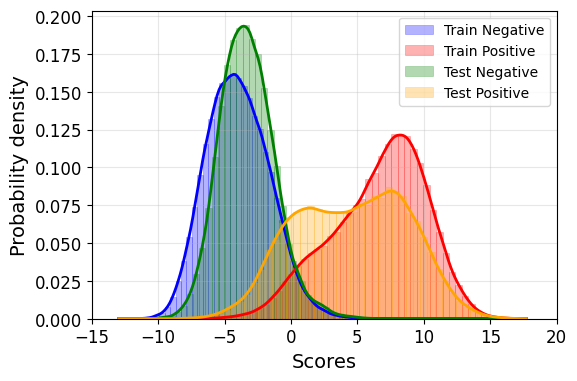

In [11]:
plot_score_distribution(
    train_scores, train_labels,
    test_scores, test_labels,
    filename="score_dist_comparison",
    bins=50,
    xlim=(-15, 20),
    show_kde=True
)

# Conditional Normalizing Flow (1D)

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Building blocks (те же, что в мультиклассе)
# ─────────────────────────────────────────────────────────────────────────────

class RobustFeatureNormalizer(nn.Module):
    def __init__(self, feature_dim, clip_val=5.0, momentum=0.01, eps=1e-6):
        super().__init__()
        self.feature_dim = feature_dim
        self.clip_val    = clip_val
        self.momentum    = momentum
        self.eps         = eps

        self.register_buffer('running_median', torch.zeros(feature_dim))
        self.register_buffer('running_iqr',    torch.ones(feature_dim))
        self.register_buffer('initialized',    torch.tensor(False))

    @torch.no_grad()
    def _update_stats(self, x):
        batch_median = x.median(dim=0).values
        q75 = torch.quantile(x, 0.75, dim=0)
        q25 = torch.quantile(x, 0.25, dim=0)
        batch_iqr = (q75 - q25).clamp(min=self.eps)

        if not self.initialized:
            self.running_median.copy_(batch_median)
            self.running_iqr.copy_(batch_iqr)
            self.initialized.fill_(True)
        else:
            self.running_median.mul_(1 - self.momentum).add_(batch_median * self.momentum)
            self.running_iqr.mul_(1 - self.momentum).add_(batch_iqr * self.momentum)

    def forward(self, x):
        if self.training:
            self._update_stats(x)
        if not self.initialized:
            return torch.tanh(x * 0.01)
        x_norm = (x - self.running_median) / (self.running_iqr + self.eps)
        x_norm = x_norm.clamp(-self.clip_val, self.clip_val)
        x_norm = torch.tanh(x_norm / self.clip_val)
        return x_norm


class ActNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim       = dim
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias      = nn.Parameter(torch.zeros(dim))
        self.register_buffer('initialized', torch.tensor(False))

    def forward(self, x, reverse=False):
        if not self.initialized and not reverse:
            with torch.no_grad():
                self.bias.data      = -x.mean(0)
                self.log_scale.data = -x.std(0).clamp(min=1e-6).log()
            self.initialized.fill_(True)

        if not reverse:
            y       = (x + self.bias) * self.log_scale.exp()
            log_det = self.log_scale.sum().expand(x.size(0))
            return y, log_det
        else:
            x_rec   = x * (-self.log_scale).exp() - self.bias
            log_det = -self.log_scale.sum().expand(x.size(0))
            return x_rec, log_det


class CouplingLayer(nn.Module):
    """
    Для бинарного случая score_dim=2:
      split: x1 = x[:, 0:1],  x2 = x[:, 1:2]
    Маски чередуются через flip — как в исходной бинарной модели.
    """
    def __init__(self, dim, feature_dim, hidden_dim=256, mask_type='first_half'):
        super().__init__()
        self.dim       = dim
        self.mask_type = mask_type

        if mask_type == 'first_half':
            self.d_in  = dim // 2          # 1
            self.d_out = dim - dim // 2    # 1
        else:
            self.d_in  = dim - dim // 2   # 1
            self.d_out = dim // 2          # 1

        net_in = self.d_in + feature_dim

        self.net = nn.Sequential(
            nn.Linear(net_in, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
        )
        self.scale_head = nn.Sequential(
            nn.Linear(hidden_dim // 2, self.d_out),
            nn.Tanh(),
        )
        self.translate_head = nn.Linear(hidden_dim // 2, self.d_out)

        nn.init.zeros_(self.scale_head[0].weight)
        nn.init.zeros_(self.scale_head[0].bias)
        nn.init.zeros_(self.translate_head.weight)
        nn.init.zeros_(self.translate_head.bias)

    def _split(self, x):
        if self.mask_type == 'first_half':
            return x[:, :self.d_in], x[:, self.d_in:]
        else:
            return x[:, self.d_out:], x[:, :self.d_out]

    def _merge(self, x1, x2):
        if self.mask_type == 'first_half':
            return torch.cat([x1, x2], dim=1)
        else:
            return torch.cat([x2, x1], dim=1)

    def forward(self, x, features, reverse=False):
        x1, x2     = self._split(x)
        cond_input = torch.cat([x1, features], dim=1)
        h          = self.net(cond_input)
        s          = self.scale_head(h)
        t          = self.translate_head(h)

        if not reverse:
            z2      = x2 * torch.exp(s) + t
            log_det = s.sum(dim=1)
            return self._merge(x1, z2), log_det
        else:
            x2_rec  = (x2 - t) * torch.exp(-s)
            log_det = -s.sum(dim=1)
            return self._merge(x1, x2_rec), log_det


# ─────────────────────────────────────────────────────────────────────────────
# Main flow — бинарный случай
# ─────────────────────────────────────────────────────────────────────────────


class ScoreShiftFlow(nn.Module):
    def __init__(self,
                 feature_dim = 256,
                 n_flows     = 12,
                 hidden_dim  = 256,
                 encoder_dim = 128,
                 clip_val    = 5.0):
        super().__init__()
        # ── Ключевое изменение: score_dim=1, без фиктивного канала ──
        self.score_dim   = 1
        self.feature_dim = feature_dim
        self._log_2pi    = float(np.log(2 * np.pi))

        self.feature_norm = RobustFeatureNormalizer(
            feature_dim, clip_val=clip_val, momentum=0.01)

        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, encoder_dim),
            nn.LayerNorm(encoder_dim),
            nn.GELU(),
        )

        # ── При score_dim=1 coupling layer не работает (нечего разбивать)
        # Используем element-wise affine flows (scale + shift) вместо coupling
        self.layers = nn.ModuleList()
        for i in range(n_flows):
            self.layers.append(
                ElementWiseAffineLayer(
                    feature_dim = encoder_dim,
                    hidden_dim  = hidden_dim,
                )
            )

    def encode(self, features):
        return self.feature_encoder(self.feature_norm(features))

    def forward(self, scores, features, reverse=False):
        enc         = self.encode(features)
        log_det_sum = torch.zeros(scores.size(0), device=scores.device)

        # scores: (B, 1) или (B,) → всегда (B, 1)
        if scores.dim() == 1:
            scores = scores.unsqueeze(1)

        if not reverse:
            x = scores
            for layer in self.layers:
                x, ld = layer(x, enc, reverse=False)
                log_det_sum = log_det_sum + ld
            return x, log_det_sum
        else:
            z = scores
            for layer in reversed(self.layers):
                z, ld = layer(z, enc, reverse=True)
                log_det_sum = log_det_sum + ld
            return z, log_det_sum

    def log_prob(self, scores, features):
        z, log_det = self.forward(scores, features, reverse=False)
        log_pz     = -0.5 * (z ** 2).sum(dim=1) \
                     - 0.5 * self.score_dim * self._log_2pi
        return log_pz + log_det

    def sample(self, features):
        z = torch.randn(features.size(0), self.score_dim, device=features.device)
        scores, _ = self.forward(z, features, reverse=True)
        return scores   # (B, 1)


class ElementWiseAffineLayer(nn.Module):
    """
    Conditioned element-wise affine transform для score_dim=1.
    
    Forward: z = x * exp(s(feat)) + t(feat)
    Reverse: x = (z - t) * exp(-s)
    
    s и t зависят только от features (не от x, т.к. x скаляр).
    Tanh на s предотвращает взрыв.
    """
    def __init__(self, feature_dim, hidden_dim=256):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
        )
        self.scale_head = nn.Sequential(
            nn.Linear(hidden_dim // 2, 1),
            nn.Tanh(),   # s ∈ (-1, 1) → exp(s) ∈ (0.37, 2.72)
        )
        self.translate_head = nn.Linear(hidden_dim // 2, 1)

        # Инициализация в тождественное преобразование
        nn.init.zeros_(self.scale_head[0].weight)
        nn.init.zeros_(self.scale_head[0].bias)
        nn.init.zeros_(self.translate_head.weight)
        nn.init.zeros_(self.translate_head.bias)

    def forward(self, x, features, reverse=False):
        h = self.net(features)
        s = self.scale_head(h)       # (B, 1)
        t = self.translate_head(h)   # (B, 1)

        if not reverse:
            z       = x * torch.exp(s) + t
            log_det = s.squeeze(1)           # (B,)
            return z, log_det
        else:
            x_rec   = (x - t) * torch.exp(-s)
            log_det = -s.squeeze(1)
            return x_rec, log_det


# Wrapper
# ─────────────────────────────────────────────────────────────────────────────

class ScoreShiftFlowWrapper(nn.Module):
    """
    Бинарная версия — полностью аналогична мультиклассовой по интерфейсу.
    """
    def __init__(self,
                 n_flows     = 12,
                 feature_dim = 256,
                 hidden_dim  = 256,
                 encoder_dim = 128,
                 clip_val    = 5.0):
        super().__init__()
        self.flow = ScoreShiftFlow(
            feature_dim = feature_dim,
            n_flows     = n_flows,
            hidden_dim  = hidden_dim,
            encoder_dim = encoder_dim,
            clip_val    = clip_val,
        )
        print("✓ ScoreShiftFlow (binary) defined")
        print(f"  score_dim=2 (internal),  clip_val={clip_val}")

    # ── Training ──────────────────────────────────────────────────────────────

    def train_flow(self,
                   score_dataset,
                   epochs     = 30,
                   lr         = 3e-4,
                   batch_size = 256,
                   device     = 'cuda',
                   patience   = 5,
                   grad_clip  = 1.0):
        self.flow.to(device)
        self.flow.train()

        loader    = DataLoader(score_dataset, batch_size=batch_size,
                               shuffle=True, num_workers=0, pin_memory=True)
        optimizer = torch.optim.AdamW(self.flow.parameters(), lr=lr,
                                      weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01)

        best_loss  = float('inf')
        best_state = None
        no_improve = 0

        for epoch in range(epochs):
            total_loss = 0.0
            n_batches  = 0

            for cnn_scores, features, target_decoy, labels in loader:
                features     = features.to(device)
                target_decoy = target_decoy.to(device)   # (B, 1)

                log_prob = self.flow.log_prob(target_decoy, features)
                loss     = -log_prob.mean()

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.flow.parameters(), grad_clip)
                optimizer.step()

                total_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            avg_loss = total_loss / max(n_batches, 1)

            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs}  "
                      f"loss={avg_loss:.4f}  "
                      f"lr={scheduler.get_last_lr()[0]:.2e}")

            if avg_loss < best_loss - 1e-4:
                best_loss  = avg_loss
                no_improve = 0
                best_state = {k: v.clone()
                              for k, v in self.flow.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    self.flow.load_state_dict(best_state)
                    break

        if best_state is not None:
            self.flow.load_state_dict(best_state)
        print(f"  ✓ Training complete. Best loss: {best_loss:.4f}")
        return self

    # ── Inference ─────────────────────────────────────────────────────────────

    def generate_decoys(self, score_dataset, device='cuda', n_samples=1):
        """
        Returns:
          cnn_scores    : (N,)    оригинальные скоры (flatten)
          decoy_scores  : (N,)    сгенерированные нулевые скоры (flatten)
          labels        : (N,)    истинные метки
        """
        self.flow.to(device)
        self.flow.eval()

        cnn_list   = []
        decoy_list = []
        lbl_list   = []

        loader = DataLoader(score_dataset, batch_size=256,
                            shuffle=False, num_workers=0)

        with torch.no_grad():
            for cnn_scores, features, target_decoy, labels in loader:
                features = features.to(device)

                if n_samples == 1:
                    decoy = self.flow.sample(features)          # (B, 1)
                else:
                    samples = torch.stack(
                        [self.flow.sample(features) for _ in range(n_samples)],
                        dim=0)
                    decoy = samples.mean(dim=0)                 # (B, 1)

                cnn_list.append(cnn_scores.cpu().numpy())
                decoy_list.append(decoy.cpu().numpy())
                lbl_list.append(labels.cpu().numpy())

        cnn_arr   = np.concatenate(cnn_list,   axis=0).flatten()
        decoy_arr = np.concatenate(decoy_list, axis=0).flatten()
        lbl_arr   = np.concatenate(lbl_list,   axis=0)

        return cnn_arr, decoy_arr, lbl_arr

    # ── OOD диагностика ───────────────────────────────────────────────────────

    def diagnose_feature_ood(self, score_dataset, device='cuda', tile_name=''):
        self.flow.to(device)
        self.flow.eval()

        norm = self.flow.feature_norm
        if not norm.initialized:
            print("  ⚠ Normalizer not initialized — train first")
            return

        loader = DataLoader(score_dataset, batch_size=256, shuffle=False)
        all_features = []
        with torch.no_grad():
            for _, features, _, _ in loader:
                all_features.append(features.to(device))
        features  = torch.cat(all_features, dim=0)

        deviation = ((features - norm.running_median) /
                     (norm.running_iqr + 1e-6)).abs()

        print(f"  OOD диагностика [{tile_name}]:")
        print(f"    median deviation (IQR units) : {deviation.median():.2f}")
        print(f"    95th pct deviation            : {deviation.quantile(0.95):.2f}")
        print(f"    max deviation                 : {deviation.max():.2f}")
        print(f"    % features с deviation >  5  : "
              f"{(deviation > 5).float().mean() * 100:.1f}%")
        print(f"    % features с deviation > 10  : "
              f"{(deviation > 10).float().mean() * 100:.1f}%")
        print(f"    % features с deviation > 100 : "
              f"{(deviation > 100).float().mean() * 100:.1f}%")


# ─────────────────────────────────────────────────────────────────────────────
# Инициализация
# ─────────────────────────────────────────────────────────────────────────────

flow_model = ScoreShiftFlowWrapper(
    n_flows     = 12,
    feature_dim = 256,   # ← поменяй под свой FEATURE_DIM
    hidden_dim  = 256,
    encoder_dim = 128,
    clip_val    = 5.0,
).to(DEVICE)

flow_model.train_flow(train_score_dataset, epochs=45, lr=3e-4, device=DEVICE)
scores_flow, decoys_flow, labels_flow = flow_model.generate_decoys(
    test_score_dataset, device=DEVICE)

✓ ScoreShiftFlow (binary) defined
  score_dim=2 (internal),  clip_val=5.0
  Epoch   5/45  loss=1.2071  lr=2.91e-04
  Epoch  10/45  loss=1.0175  lr=2.65e-04
  Epoch  15/45  loss=0.8752  lr=2.26e-04
  Epoch  20/45  loss=0.6742  lr=1.77e-04
  Epoch  25/45  loss=0.5283  lr=1.26e-04
  Epoch  30/45  loss=0.3609  lr=7.73e-05
  Epoch  35/45  loss=0.1603  lr=3.77e-05
  Epoch  40/45  loss=0.0369  lr=1.20e-05
  Epoch  45/45  loss=0.0693  lr=3.00e-06
  Early stopping at epoch 45
  ✓ Training complete. Best loss: 0.0369


In [33]:
# print("Training Normalizing Flow...")

# flow_model = ScoreShiftFlowWrapper(
#     n_flows     = 12,
#     feature_dim = 256,   # ← поменяй под свой FEATURE_DIM
#     hidden_dim  = 256,
#     encoder_dim = 128,
#     clip_val    = 5.0,
# ).to(DEVICE)

# flow_model.train_flow(train_score_dataset, epochs=30, lr=3e-4, device=DEVICE)
# scores_flow, decoys_flow, labels_flow = flow_model.generate_decoys(
#     test_score_dataset, device=DEVICE)

In [34]:
torch.save(flow_model.state_dict(), 'cond_flows_model_normalized.pth')

In [35]:
# flow_model = ConditionalNormalizingFlow(n_flows=15, feature_dim=256, hidden_dim=64).to(DEVICE)
flow_model.load_state_dict(torch.load('cond_flows_model_normalized.pth'))
scores_flow, decoys_flow, labels_flow = flow_model.generate_decoys(test_score_dataset, device='cuda')

In [36]:
def plot_score_distributions(model_scores, decoy_scores, labels, method_name, bins=50):
    fig, ax = plt.subplots(figsize=(10, 6))

    null_scores = model_scores[labels == 0]
    positive_scores = model_scores[labels == 1]

    ax.hist(null_scores, bins=bins, alpha=0.5, label='True Null (Negative Class)',
            color='red', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(decoy_scores, bins=bins, alpha=0.5, label='Generated Decoys',
            color='blue', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(positive_scores, bins=bins, alpha=0.3, label='Positive Class',
            color='green', density=True, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Score Distribution Analysis - {method_name}', fontsize=16, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [37]:
def plot_score_distributions_with_train(model_scores, decoy_scores, labels, method_name, bins=50):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    null_scores = model_scores[labels == 0]
    positive_scores = model_scores[labels == 1]

    # Отрисовка всех распределений
    ax.hist(null_scores, bins=bins, alpha=0.4, label='True Null (Negative Class)',
            color='red', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(TRAIN_NULL_SCORES, bins=bins, alpha=0.4, label='Train Null Scores',
            color='orange', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(decoy_scores, bins=bins, alpha=0.4, label='Generated Decoys',
            color='blue', density=True, edgecolor='black', linewidth=0.5)
    
    ax.hist(positive_scores, bins=bins, alpha=0.3, label='Positive Class',
            color='green', density=True, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Score', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Score Distribution Analysis - {method_name}', fontsize=16, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Использование


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_score_differences(scores_diff, decoys_diff, labels, title="Score Differences Comparison"):
    plt.figure(figsize=(8, 8))
    
    # Split data by labels
    mask_null = (labels == 0)
    mask_positive = (labels == 1)
    
    # Plot points with different colors
    plt.scatter(scores_diff[mask_null], decoys_diff[mask_null], 
                color='blue', alpha=0.5, label='Negative Class (0)')
    plt.scatter(scores_diff[mask_positive], decoys_diff[mask_positive], 
                color='red', alpha=0.5, label='Positive Class (1)')
    
    # Plot diagonal line (x = y)
    min_val = min(np.min(scores_diff), np.min(decoys_diff))
    max_val = max(np.max(scores_diff), np.max(decoys_diff))
    plt.plot([min_val, max_val], [min_val, max_val], 
             'k--', linewidth=1, label='x = y')
    
    # Add labels and title
    plt.xlabel('Original Scores Difference', fontsize=12)
    plt.ylabel('Decoy Scores Difference', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [39]:
scores_flow_train, decoys_flow_train, labels_flow_train = flow_model.generate_decoys(train_score_dataset, device='cuda')

In [40]:
TRAIN_NULL_SCORES = scores_flow_train[labels_flow_train == 0]

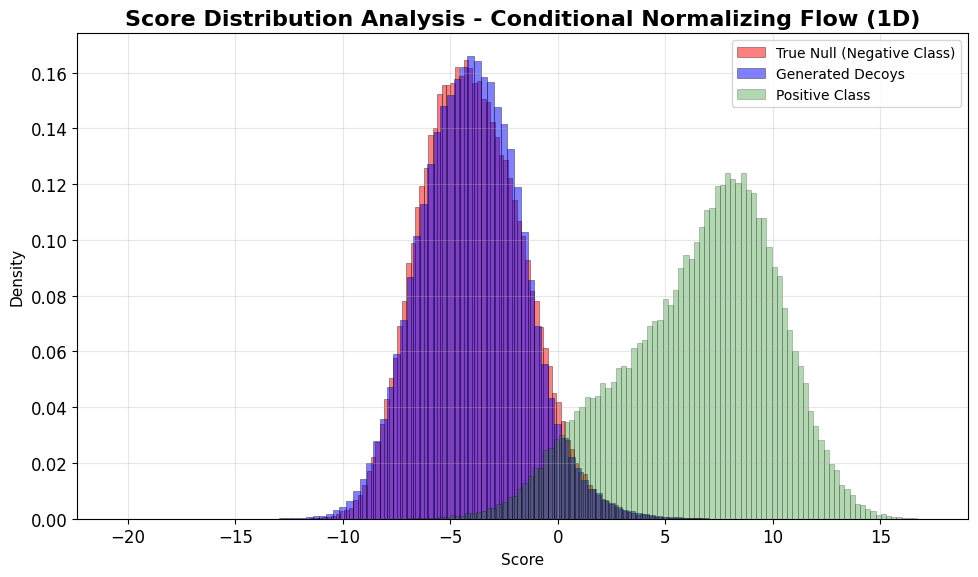

In [41]:
plot_score_distributions(scores_flow_train, decoys_flow_train, labels_flow_train, 'Conditional Normalizing Flow (1D)', bins=100)

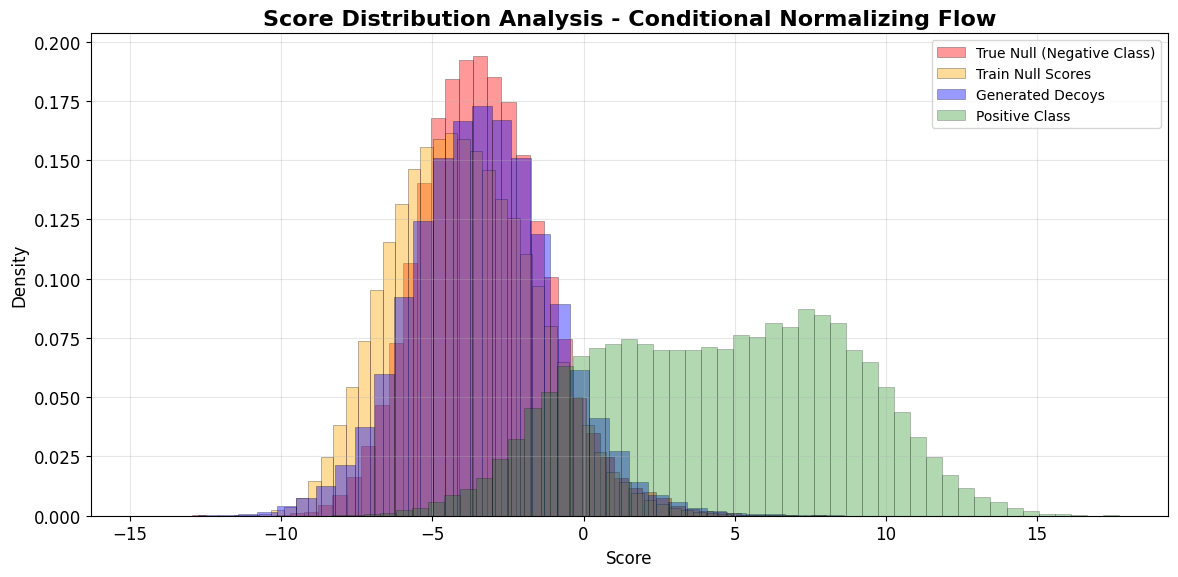

In [42]:
plot_score_distributions_with_train(scores_flow, decoys_flow, labels_flow, 
                         method_name="Conditional Normalizing Flow")

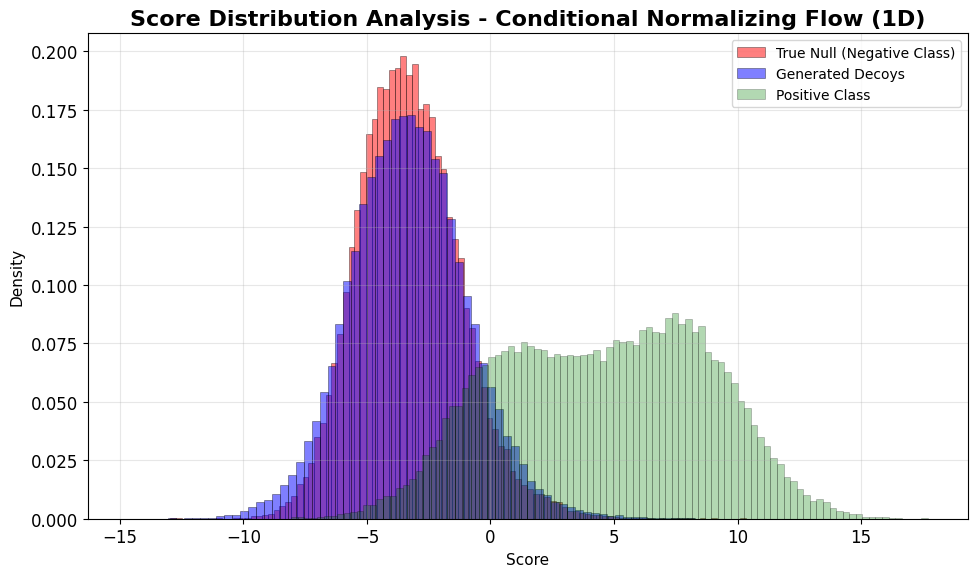

In [43]:
plot_score_distributions(scores_flow, decoys_flow, labels_flow, 'Conditional Normalizing Flow (1D)', bins=100)

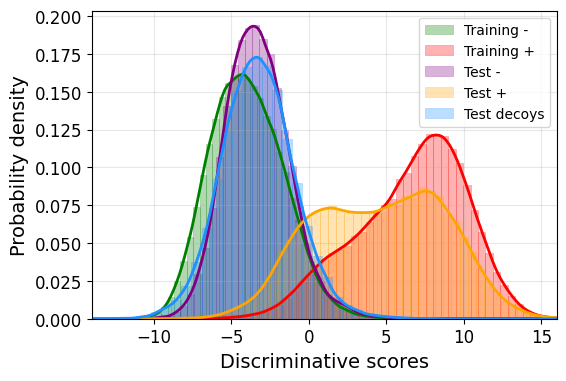

In [44]:
plot_score_distribution_with_decoys(scores_flow_train, labels_flow_train, 
                                        scores_flow, labels_flow, 
                                        decoys_flow,
                                        filename="score_distribution_decoys", 
                                        title="Score Distribution with Decoys",
                                        bins=50, xlim=(-14, 16), show_kde=True)

Discriminative scores
Training +
Test decoys

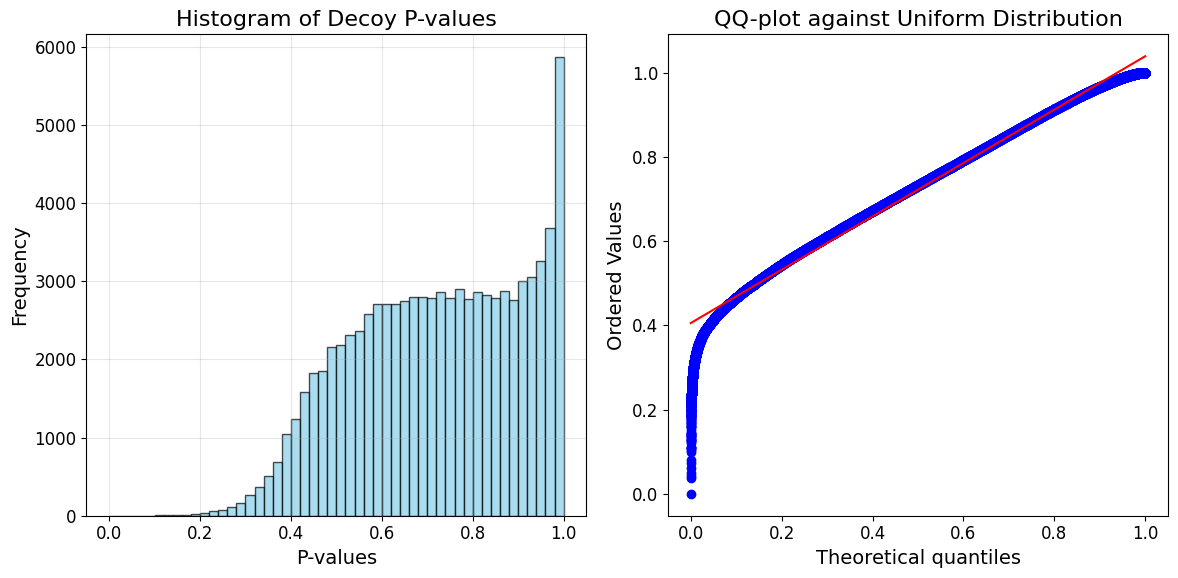

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from bisect import bisect

def empirical_p_values(distribution, query):
    """empirical p-value calculation"""
    dist_len = len(distribution)
    query_len = len(query)
    p_values = np.zeros(query_len)

    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(distribution, score)) / dist_len
    
    return p_values

# Вычислим p-значения для декаев
p_values_decoy = empirical_p_values(np.sort(scores_flow), decoys_flow)

# Построим гистограмму
plt.figure(figsize=(12, 6))

# Гистограмма p-значений
plt.subplot(1, 2, 1)
plt.hist(p_values_decoy, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('P-values')
plt.ylabel('Frequency')
plt.title('Histogram of Decoy P-values')
plt.grid(True, alpha=0.3)

# QQ-plot для проверки равномерности
plt.subplot(1, 2, 2)
stats.probplot(p_values_decoy, dist="uniform", plot=plt)
plt.title('QQ-plot against Uniform Distribution')

plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests
from bisect import bisect
import os
from sklearn.neighbors import KernelDensity



def empirical_p_values(distribution, query):
    dist_len = len(distribution)
    query_len = len(query)
    p_values = np.zeros(query_len)
    sorted_dist = np.sort(distribution)
    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(sorted_dist, score)) / dist_len

    return p_values


def estimate_pi0_storey(p_values, lambda_range=np.arange(0.05, 0.95, 0.05)):
    pi0_estimates = []
    for lam in lambda_range:
        pi0_lam = np.mean(p_values > lam) / (1 - lam)
        pi0_estimates.append(pi0_lam)
    pi0 = np.mean(pi0_estimates)
    return min(1.0, max(0, pi0))


def benjamini_hochberg_storey(p_values):
    n = len(p_values)
    pi0 = estimate_pi0_storey(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value

    return q_values


def benjamini_hochberg_fixed(p_values, pi0=1.0):
    n = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value

    return q_values


def calculate_qvalues_from_pvalues(distribution, query, pi_0=0.9):
    p_values = empirical_p_values(np.sort(distribution), query)
    q_values = p_values * len(p_values) * pi_0
    q_values = q_values / np.arange(1, len(p_values) + 1)
    for i in range(len(p_values)-1, 0, -1):
        q_values[i-1] = min(q_values[i-1], q_values[i])
    return np.sort(q_values)


def negative_training_benchmark(train_cnn_scores, train_labels, test_cnn_scores,
                                target_class, fdr_level=0.05):
    neg_train_mask = (train_labels != target_class)
    null_distribution = train_cnn_scores[neg_train_mask]
    test_scores = test_cnn_scores
    p_values = empirical_p_values(null_distribution, test_scores)
    q_values = benjamini_hochberg_storey(np.sort(p_values))
    n_discoveries = (q_values <= fdr_level).sum()
    return n_discoveries, q_values, p_values

def control_fdr(model_scores, target_labels, decoys,
                train_cnn_scores=None, train_labels=None,
                test_cnn_scores=None, target_class=None):
    
    # Create dataframe with original index preserved
    df = pd.DataFrame({
        'model_score': model_scores,
        'label': target_labels,
        'decoy_score': decoys,
        'original_index': np.arange(len(model_scores))
    })
    
    # Compute p-values first (before any sorting)
    df['p_value'] = empirical_p_values(np.sort(decoys), model_scores)
    
    # Compute q-values using BH (before any sorting)
    df['q_values_bh_storey'] = benjamini_hochberg_storey(df['p_value'].values)
    df['q_values_bh_fixed'] = benjamini_hochberg_fixed(df['p_value'].values)
    
    # Now sort by model_score for ground truth FDR calculation
    df = df.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    
    # Ground truth FDR
    df['fdr'] = 0.0
    num_neg = 0
    num_pos = 0
    
    for index, row in df.iterrows():
        if row['label'] == 0:
            num_neg += 1
        else:
            num_pos += 1
        if num_pos + num_neg > 0:
            df.at[index, 'fdr'] = (num_neg + 1.0) / (num_pos + num_neg)
    
    df['q_values_ground_truth'] = df['fdr'].copy()
    prev = 1
    for index in range(len(df) - 1, -1, -1):
        df.loc[index, 'q_values_ground_truth'] = min(prev, df.loc[index, 'q_values_ground_truth'])
        prev = df.loc[index, 'q_values_ground_truth']
    
    # TDC method - compute on sorted data by max_score
    df['max_score'] = df[['model_score', 'decoy_score']].max(axis=1)
    
    # Sort by max_score for TDC, preserving original_index
    df_sorted_by_max = df.sort_values(by='max_score', ascending=False).reset_index(drop=True)
    
    fdr_tdc_list = []
    num_decoy_wins = 0
    num_target_wins = 0
    
    for index, row in df_sorted_by_max.iterrows():
        if row['model_score'] >= row['decoy_score']:  # Target wins
            num_target_wins += 1
            if num_target_wins > 0:
                fdr_tdc_list.append((num_decoy_wins + 1.0) / num_target_wins)
            else:
                fdr_tdc_list.append(1.0)
        else:  # Decoy wins - not counted as discovery
            num_decoy_wins += 1
            fdr_tdc_list.append(np.nan)  # No FDR value for decoy wins
    
    df_sorted_by_max['fdr_tdc'] = fdr_tdc_list
    
    # Make monotone (only for target wins)
    q_values_tdc_list = df_sorted_by_max['fdr_tdc'].tolist()
    prev = 1.0
    for index in range(len(q_values_tdc_list) - 1, -1, -1):
        if not np.isnan(q_values_tdc_list[index]):
            q_values_tdc_list[index] = min(prev, q_values_tdc_list[index])
            prev = q_values_tdc_list[index]
    
    df_sorted_by_max['q_values_tdc'] = q_values_tdc_list
    
    # Map TDC q-values back using original_index
    tdc_mapping = dict(zip(df_sorted_by_max['original_index'], 
                           df_sorted_by_max['q_values_tdc']))
    df['q_values_tdc'] = df['original_index'].map(tdc_mapping)
    
    if (train_cnn_scores is not None and train_labels is not None and
        test_cnn_scores is not None and target_class is not None):
        # Negative training - compute on original order using original_index
        neg_train_mask = (train_labels != target_class)
        null_distribution = train_cnn_scores[neg_train_mask]
        
        # Create mapping from original_index to values
        p_values_neg_full = empirical_p_values(null_distribution, model_scores)
        q_values_neg_full = benjamini_hochberg_storey(p_values_neg_full)
        
        # Map to current df using original_index
        neg_p_mapping = dict(zip(np.arange(len(model_scores)), p_values_neg_full))
        neg_q_mapping = dict(zip(np.arange(len(model_scores)), q_values_neg_full))
        
        df['p_values_negative_training'] = df['original_index'].map(neg_p_mapping)
        df['q_values_negative_training'] = df['original_index'].map(neg_q_mapping)
    
    return df

def plot_fdr_comprehensive(df, filename="fdr_comprehensive"):
    """Comprehensive FDR plot with all methods"""
    plt.figure(figsize=(6, 4))  # Updated figure size
    
    methods = [
        ('q_values_tdc', 'TDC', 'blue', '-'),
        ('q_values_ground_truth', 'Ground Truth', 'green', '-'),
        ('q_values_bh_storey', 'BH (Storey π₀)', 'red', '-'),
    ]
    if 'q_values_negative_training' in df.columns:
        methods.append(('q_values_negative_training', 'Negative Training', 'orange', ':'))
    
    for col_name, label, color, linestyle in methods:
        df_sorted = df.sort_values(by=col_name, ascending=True).reset_index(drop=True)
        plt.plot(df_sorted[col_name], np.arange(len(df_sorted)), 
                marker='none', linestyle=linestyle, label=label, linewidth=2, color=color)
    
    plt.ylabel('Number of Discoveries')
    plt.xlabel('Q-values')
    plt.title('Comparison of FDR Control Methods')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, 1)
    
    # Save in both formats
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()
    
    return plt

P-values monotone check: True
Q-values monotone check: True


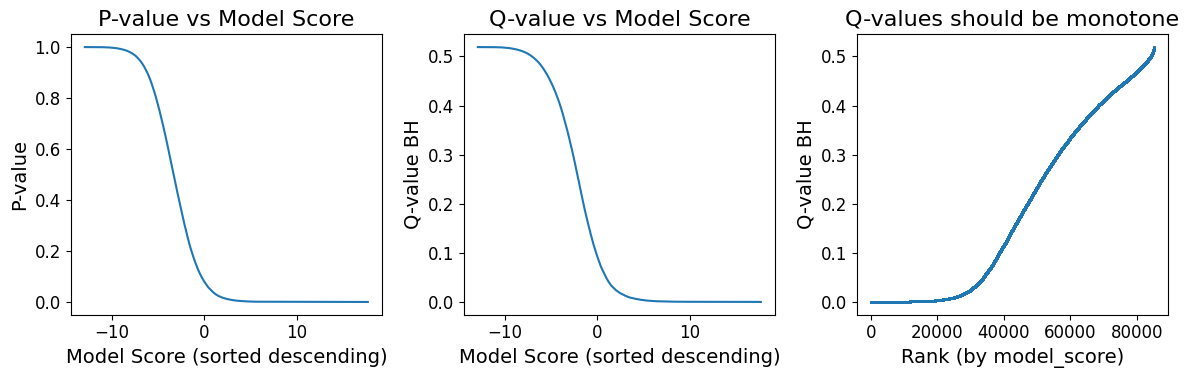

In [47]:
df_flow = control_fdr(scores_flow, labels_flow, decoys_flow, 
                      scores_flow_train.flatten(), labels_flow_train,
                      scores_flow, target_class=1)

# Check monotonicity (df is sorted by model_score descending)
print("P-values monotone check:", np.all(np.diff(df_flow['p_value']) >= -1e-10))
print("Q-values monotone check:", np.all(np.diff(df_flow['q_values_bh_storey']) >= -1e-10))

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(df_flow['model_score'].values, df_flow['p_value'].values)
plt.xlabel('Model Score (sorted descending)')
plt.ylabel('P-value')
plt.title('P-value vs Model Score')

plt.subplot(1, 3, 2)
plt.plot(df_flow['model_score'].values, df_flow['q_values_bh_storey'].values)
plt.xlabel('Model Score (sorted descending)')
plt.ylabel('Q-value BH')
plt.title('Q-value vs Model Score')

plt.subplot(1, 3, 3)
plt.scatter(range(len(df_flow)), df_flow['q_values_bh_storey'].values, s=1)
plt.xlabel('Rank (by model_score)')
plt.ylabel('Q-value BH')
plt.title('Q-values should be monotone')
plt.tight_layout()
plt.show()

In [48]:
def plot_fdr_comprehensive(df, filename="fdr_comprehensive"):
    """Comprehensive FDR plot with all methods"""
    
    methods = [
        ('q_values_ground_truth', 'Ground Truth', 'green', '-'),
        ('q_values_bh_storey', 'BH (Storey π₀)', 'red', '-'),
        ('q_values_tdc', 'TDC', 'blue', '-'),
    ]
    if 'q_values_negative_training' in df.columns:
        methods.append(('q_values_negative_training', 'Negative Training', 'orange', ':'))
    
    # Создаем два графика с разными xlim
    xlim_configs = [
        (1.0, "full"),    # График до 1.0
        (0.2, "zoom")     # График до 0.2
    ]
    
    for xmax, suffix in xlim_configs:
        plt.figure(figsize=(6, 4))  # Updated figure size
        
        for col_name, label, color, linestyle in methods:
            df_sorted = df.sort_values(by=col_name, ascending=True).reset_index(drop=True)
            plt.plot(df_sorted[col_name], np.arange(len(df_sorted)), 
                    marker='none', linestyle=linestyle, label=label, linewidth=2, color=color)
        
        plt.ylabel('Number of discoveries')
        plt.xlabel('Estimated FDR (Q-values)')
        plt.title(f'Comparison of FDR Control Methods')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xlim(0, xmax)
        
        # Сохраняем с разными именами файлов
        plt.savefig(PATH + f"{filename}_{suffix}.png", bbox_inches='tight', dpi=300)
        plt.savefig(PATH + f"{filename}_{suffix}.pdf", bbox_inches='tight')
        plt.show()
    
    return plt

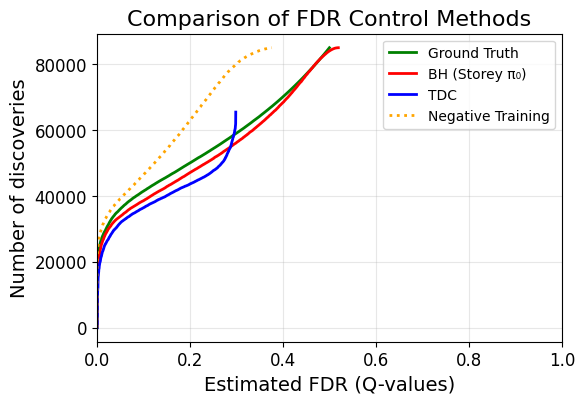

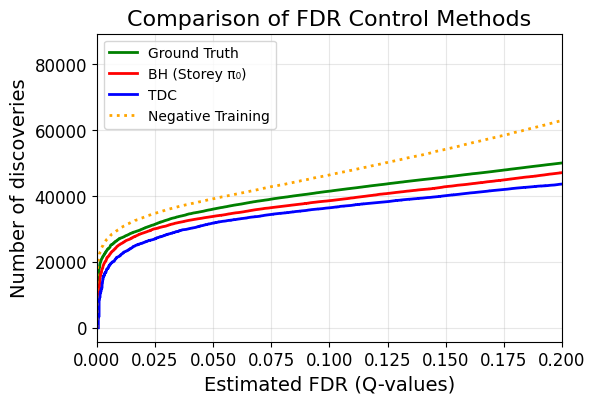

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

In [49]:
plot_fdr_comprehensive(df_flow)

gt first 0.2

X LABELE ESTIMATED FDR (Q-VALUES)

x 0.2 DELETE

Estimated π₀: 0.519


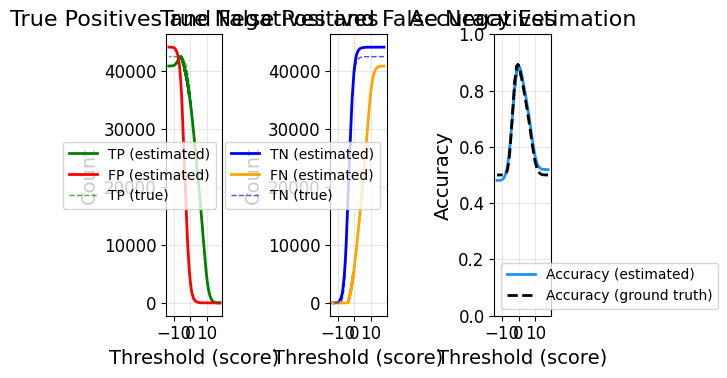

In [50]:
def estimate_confusion_matrix_1(df, pi0):
    """
    Estimate TP, FP, TN, FN, and Accuracy for each threshold based on FDP and pi0
    
    Parameters:
    -----------
    df : DataFrame with 'model_score' and FDR estimates
    pi0 : estimated proportion of nulls
    
    Returns:
    --------
    DataFrame with confusion matrix estimates and accuracy
    """
    df_cm = df.copy()
    total_samples = len(df)
    
    # Sort by model score descending (from highest to lowest threshold)
    df_cm = df_cm.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    
    # Threshold is the model_score at each position
    df_cm['threshold'] = df_cm['model_score']
    
    # Number of discoveries at this threshold (samples with score >= threshold)
    df_cm['n_discoveries'] = np.arange(1, len(df_cm) + 1)
    
    # Estimate confusion matrix components using formulas from Section 5
    # FP(s_th) = |{f(t) >= s_th}| * FDP(s_th)
    df_cm['FP_est'] = df_cm['n_discoveries'] * (df_cm['q_values_bh_storey'])
    
    # TP(s_th) = |{f(t) >= s_th}| * (1 - FDP(s_th))
    df_cm['TP_est'] = df_cm['n_discoveries'] * (1 - df_cm['q_values_bh_storey'])
    
    # TN(s_th) = |T| * pi0 - FP(s_th)
    df_cm['TN_est'] = total_samples * pi0 - df_cm['FP_est']
    
    # FN(s_th) = |T| * (1 - pi0) - TP(s_th)
    df_cm['FN_est'] = total_samples * (1 - pi0) - df_cm['TP_est']
    
    # Accuracy = (TP + TN) / |T|
    df_cm['Accuracy_est'] = (df_cm['TP_est'] + df_cm['TN_est']) / total_samples
    
    # Ground truth accuracy for comparison
    # At each threshold: TP_true = positives with score >= threshold
    #                    TN_true = negatives with score < threshold
    df_cm['TP_true'] = (df_cm['label'] == 1).cumsum()
    df_cm['TN_true'] = (df_cm['label'] == 0).sum() - (df_cm['label'] == 0).cumsum()
    df_cm['Accuracy_true'] = (df_cm['TP_true'] + df_cm['TN_true']) / total_samples
    
    return df_cm


def estimate_confusion_matrix(df, pi0):
    """
    Estimate TP, FP, TN, FN, and Accuracy for each threshold based on FDP and pi0
    
    Parameters:
    -----------
    df : DataFrame with 'model_score' and FDR estimates (must be sorted by model_score descending)
    pi0 : estimated proportion of nulls
    
    Returns:
    --------
    DataFrame with confusion matrix estimates and accuracy
    """
    df_cm = df.copy()
    total_samples = len(df)
    
    # Make sure we're sorted by model score descending
    df_cm = df_cm.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    
    # Threshold is the model_score at each position
    df_cm['threshold'] = df_cm['model_score']
    
    # Number of discoveries at this threshold (samples with score >= threshold)
    # This is just the rank (1, 2, 3, ...)
    df_cm['n_discoveries'] = np.arange(1, len(df_cm) + 1)
    
    # For each threshold, estimate FDP using p-values and BH procedure
    # The q-value at position i tells us the FDR if we make i discoveries
    # But we want the FDP at each threshold
    
    # Method 1: Use p-values directly to estimate FDP
    # At threshold corresponding to rank i:
    # Expected number of false positives = n_discoveries * p_value * pi0
    # (because p_value estimates P(null score >= threshold))
    
    # FDP estimate at each threshold
    df_cm['FDP_est'] = df_cm['p_value'] * pi0
    
    # Now compute confusion matrix
    # FP(s_th) = |{f(t) >= s_th}| * FDP(s_th)
    df_cm['FP_est'] = df_cm['n_discoveries'] * df_cm['FDP_est']
    
    # TP(s_th) = |{f(t) >= s_th}| * (1 - FDP(s_th))
    df_cm['TP_est'] = df_cm['n_discoveries'] * (1 - df_cm['FDP_est'])
    
    # TN(s_th) = |T| * pi0 - FP(s_th)
    df_cm['TN_est'] = total_samples * pi0 - df_cm['FP_est']
    
    # FN(s_th) = |T| * (1 - pi0) - TP(s_th)
    df_cm['FN_est'] = total_samples * (1 - pi0) - df_cm['TP_est']
    
    # Clip negative values (can happen due to estimation error)
    df_cm['FP_est'] = np.maximum(0, df_cm['FP_est'])
    df_cm['TP_est'] = np.maximum(0, df_cm['TP_est'])
    df_cm['TN_est'] = np.maximum(0, df_cm['TN_est'])
    df_cm['FN_est'] = np.maximum(0, df_cm['FN_est'])
    
    # Accuracy = (TP + TN) / |T|
    df_cm['Accuracy_est'] = (df_cm['TP_est'] + df_cm['TN_est']) / total_samples
    
    # Ground truth accuracy for comparison
    # At each threshold: TP_true = positives with score >= threshold
    #                    TN_true = negatives with score < threshold
    df_cm['TP_true'] = (df_cm['label'] == 1).cumsum()
    df_cm['FP_true'] = (df_cm['label'] == 0).cumsum()
    df_cm['TN_true'] = (df_cm['label'] == 0).sum() - df_cm['FP_true']
    df_cm['FN_true'] = (df_cm['label'] == 1).sum() - df_cm['TP_true']
    df_cm['Accuracy_true'] = (df_cm['TP_true'] + df_cm['TN_true']) / total_samples
    
    return df_cm


def estimate_confusion_matrix_v2(df, pi0):
    """
    Alternative version using q-values directly
    """
    df_cm = df.copy()
    total_samples = len(df)
    
    df_cm = df_cm.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    df_cm['threshold'] = df_cm['model_score']
    df_cm['n_discoveries'] = np.arange(1, len(df_cm) + 1)
    
    # q-value IS the FDR estimate for making n_discoveries
    # So: E[FP] = n_discoveries * q_value
    df_cm['FP_est'] = df_cm['n_discoveries'] * df_cm['q_values_bh_storey']
    df_cm['TP_est'] = df_cm['n_discoveries'] - df_cm['FP_est']
    
    # For TN and FN, we need pi0
    df_cm['TN_est'] = total_samples * pi0 - df_cm['FP_est']
    df_cm['FN_est'] = total_samples * (1 - pi0) - df_cm['TP_est']
    
    df_cm['FP_est'] = np.maximum(0, df_cm['FP_est'])
    df_cm['TP_est'] = np.maximum(0, df_cm['TP_est'])
    df_cm['TN_est'] = np.maximum(0, df_cm['TN_est'])
    df_cm['FN_est'] = np.maximum(0, df_cm['FN_est'])
    
    df_cm['Accuracy_est'] = (df_cm['TP_est'] + df_cm['TN_est']) / total_samples
    
    # Ground truth
    df_cm['TP_true'] = (df_cm['label'] == 1).cumsum()
    df_cm['FP_true'] = (df_cm['label'] == 0).cumsum()
    df_cm['TN_true'] = (df_cm['label'] == 0).sum() - df_cm['FP_true']
    df_cm['FN_true'] = (df_cm['label'] == 1).sum() - df_cm['TP_true']
    df_cm['Accuracy_true'] = (df_cm['TP_true'] + df_cm['TN_true']) / total_samples
    
    return df_cm


def plot_confusion_matrix_analysis(df, pi0, filename="confusion_matrix_analysis"):
    """
    Create a 3-panel plot showing:
    1. TP and FP estimates vs threshold
    2. TN and FN estimates vs threshold
    3. Accuracy estimates vs threshold
    """
    df_cm = estimate_confusion_matrix_v2(df, pi0)

    plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 16,      # Axis titles
    'axes.labelsize': 14,      # Axis labels
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 10,     # Legend (increased from 10)
    'figure.titlesize': 18     # Figure title
})

    
    fig, axes = plt.subplots(1, 3, figsize=(6, 4))
    
    # Panel 1: TP and FP vs threshold
    axes[0].plot(df_cm['threshold'], df_cm['TP_est'], 
                 label='TP (estimated)', color='green', linewidth=2)
    axes[0].plot(df_cm['threshold'], df_cm['FP_est'], 
                 label='FP (estimated)', color='red', linewidth=2)
    # Add ground truth for comparison
    axes[0].plot(df_cm['threshold'], df_cm['TP_true'], 
                 label='TP (true)', color='green', linewidth=1, linestyle='--', alpha=0.7)
    axes[0].set_xlabel('Threshold (score)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('True Positives and False Positives')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: TN and FN vs threshold
    axes[1].plot(df_cm['threshold'], df_cm['TN_est'], 
                 label='TN (estimated)', color='blue', linewidth=2)
    axes[1].plot(df_cm['threshold'], df_cm['FN_est'], 
                 label='FN (estimated)', color='orange', linewidth=2)
    # Add ground truth for comparison
    axes[1].plot(df_cm['threshold'], df_cm['TN_true'], 
                 label='TN (true)', color='blue', linewidth=1, linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Threshold (score)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('True Negatives and False Negatives')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: Accuracy vs threshold
    axes[2].plot(df_cm['threshold'], df_cm['Accuracy_est'], 
                 label='Accuracy (estimated)', color='dodgerblue', linewidth=2, linestyle='-')
    axes[2].plot(df_cm['threshold'], df_cm['Accuracy_true'], 
                 label='Accuracy (ground truth)', color='black', linewidth=2, linestyle='--')
    axes[2].set_xlabel('Threshold (score)')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Accuracy Estimation')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()
    
    return df_cm


# Usage:
p_values = empirical_p_values(np.sort(decoys_flow), scores_flow)
pi0_estimated = estimate_pi0_storey(p_values)

print(f"Estimated π₀: {pi0_estimated:.3f}")

df_cm = plot_confusion_matrix_analysis(df_flow, pi0_estimated, 
                                       filename="confusion_matrix_analysis")

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_fn_accuracy_comparison(df, pi0, filename="fp_fn_accuracy_comparison"):
    np.set_printoptions(threshold=np.inf)

    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 10,
        'figure.titlesize': 18
    })

    df_cm = estimate_confusion_matrix_v2(df, pi0)

    fig, ax1 = plt.subplots(figsize=(6, 4), constrained_layout=True)

    # --- LEFT AXIS: FP / FN ---
    line_fp_est, = ax1.plot(
        df_cm['threshold'], df_cm['FP_est'],
        color='red', linewidth=2, label='FP (est)'
    )
    line_fp_true, = ax1.plot(
        df_cm['threshold'], df_cm['FP_true'],
        color='red', linestyle='--', linewidth=1, alpha=0.7,
        label='FP (true)'
    )

    line_fn_est, = ax1.plot(
        df_cm['threshold'], df_cm['FN_est'],
        color='orange', linewidth=2, label='FN (est)'
    )
    line_fn_true, = ax1.plot(
        df_cm['threshold'], df_cm['FN_true'],
        color='orange', linestyle='--', linewidth=1, alpha=0.7,
        label='FN (true)'
    )

    ax1.set_xlabel('Threshold (score)')
    ax1.set_ylabel('FP / FN count')
    ax1.grid(True, alpha=0.3)

    # --- RIGHT AXIS: ACCURACY ---
    ax2 = ax1.twinx()

    line_acc_est, = ax2.plot(
        df_cm['threshold'], df_cm['Accuracy_est'],
        color='dodgerblue', linewidth=2, label='Accuracy (est)'
    )
    line_acc_true, = ax2.plot(
        df_cm['threshold'], df_cm['Accuracy_true'],
        color='black', linestyle='--', linewidth=2,
        label='Accuracy (true)'
    )

    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)

    # --- LEGENDS: SPLIT & NON-OVERLAPPING ---

    # FP / FN legend (left)
    ax1.legend(
        handles=[line_fp_est, line_fp_true, line_fn_est, line_fn_true],
        loc='lower left',
        frameon=True
    )

    # Accuracy legend (right)
    ax2.legend(
        handles=[line_acc_est, line_acc_true],
        loc='lower right',
        frameon=True
    )

    ax1.set_title('FP/FN and Accuracy vs Threshold')

    plt.savefig(PATH + filename + ".png", dpi=300)
    plt.savefig(PATH + filename + ".pdf")
    plt.show()

    return df_cm

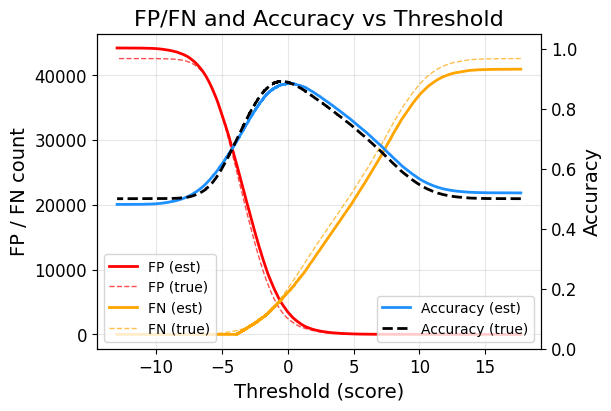

In [52]:
df_cm = plot_fp_fn_accuracy_comparison(df_flow, pi0_estimated, 
                                       filename="fp_fn_accuracy_comparison")

In [53]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.4 MB/s eta 0:00:0000:01


NumPy version: 1.26.4
PyTorch version: 2.6.0+cu124
Device: cuda
✓ Setup complete


2026-04-22 11:32:44.108608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776857564.350172      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776857564.414502      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ COT available
✓ Baseline methods (binary): ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']
✓ All helper functions loaded
Test scores shape: (85054,)
Test decoys shape: (85054,)
Test labels shape: (85054,)
Train scores shape: (243669,)

STEP 1: Binary FDR Control
DataFrame shape: (85054, 13)
Columns: ['model_score', 'label', 'decoy_score', 'original_index', 'p_value', 'q_values_bh_storey', 'q_values_bh_fixed', 'fdr', 'q_values_ground_truth', 'max_score', 'q_values_tdc', 'p_values_negative_training', 'q_values_negative_training']

STEP 2: Monotonicity and Diagnostics
P-values monotone check: True
Q-values monotone check: True


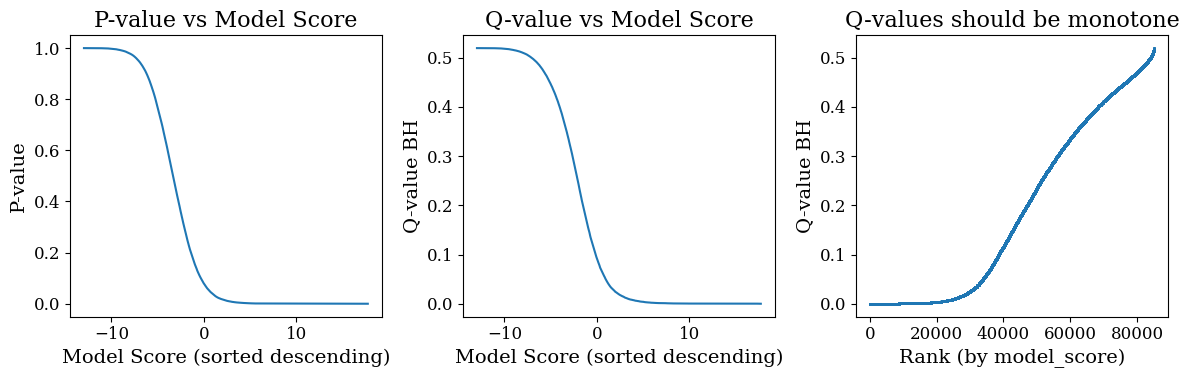


STEP 3: FDR Curves


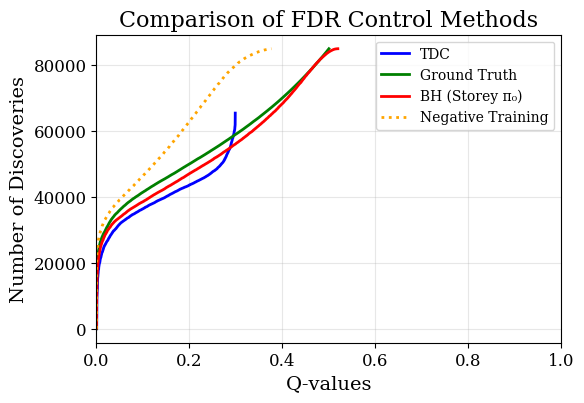


STEP 4: Confusion Matrix Analysis
Estimated π₀: 0.519
True π₀ (proportion of label==0): 0.500
|π₀ error|: 0.019


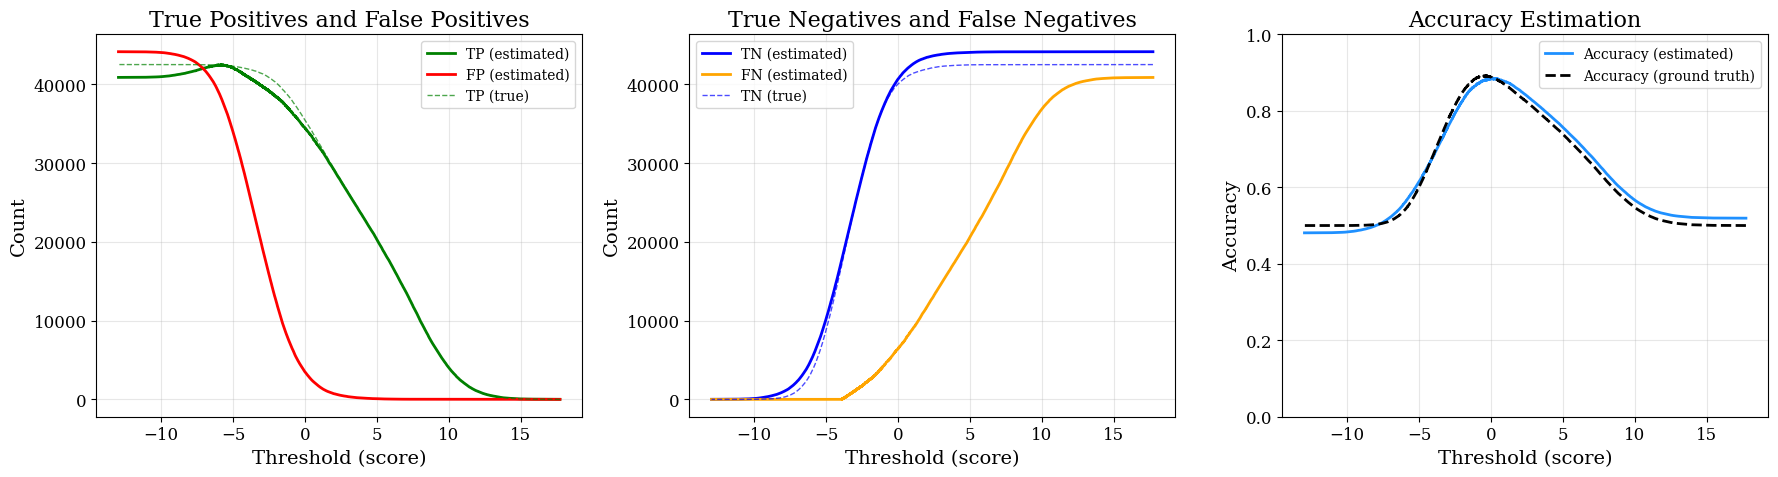

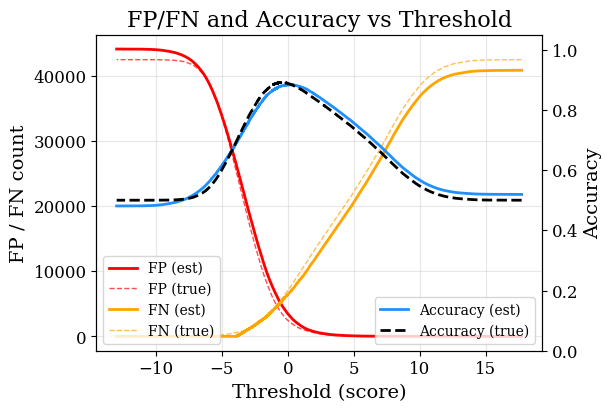


STEP 5: Comparison with Baselines
✓ Calibration temperature: 0.879
True accuracy: 0.8882
Best (oracle) accuracy: 0.8911 at threshold -0.4129
True accuracy at best threshold: 0.8911
Our method estimated accuracy (estimated π₀=0.519): 0.8839
Our method estimated accuracy (true π₀=0.500): 0.8647
  ATC: 0.9243
  ATC-NE: 0.9243
  AC: 0.9256
  DOC: 0.9269
  COT: 0.9150

✓ Processed 1 dataset(s)

π₀ ESTIMATION DIAGNOSTICS

Overall π₀ Statistics:
  Mean π₀ estimated: 0.519 ± 0.000
  Mean π₀ true:      0.500 ± 0.000
  Mean π₀ error:     0.019 ± 0.000

COMPUTING ERRORS

Mean Absolute Error (MAE) vs True Accuracy:
------------------------------------------------------------
ours_est                 : 0.0043 ± nan
ours_est_true_pi0        : 0.0235 ± nan
ATC                      : 0.0362 ± nan
ATC-NE                   : 0.0362 ± nan
AC                       : 0.0375 ± nan
DOC                      : 0.0387 ± nan
COT                      : 0.0269 ± nan

Mean Absolute Error (MAE) vs True Accuracy at 

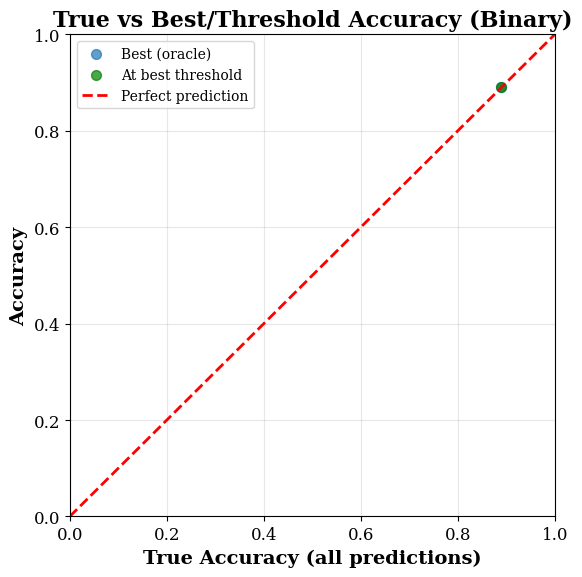

✓ Saved: scatter_true_vs_best_binary


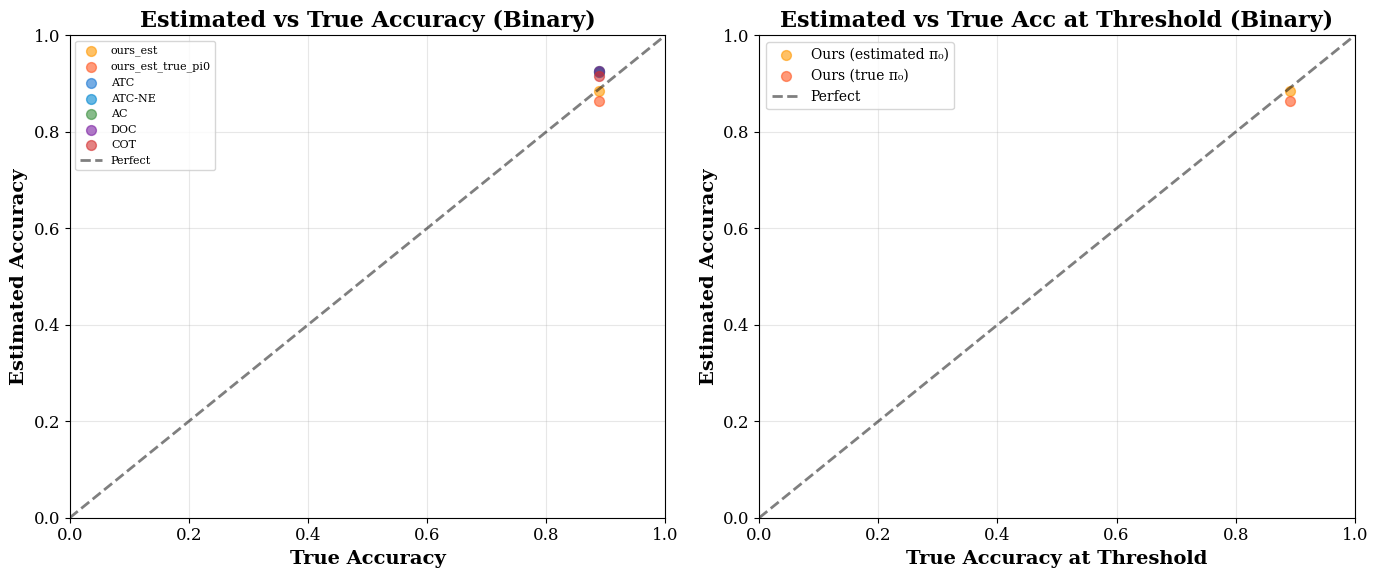

✓ Saved: scatter_est_vs_true_comparison_binary


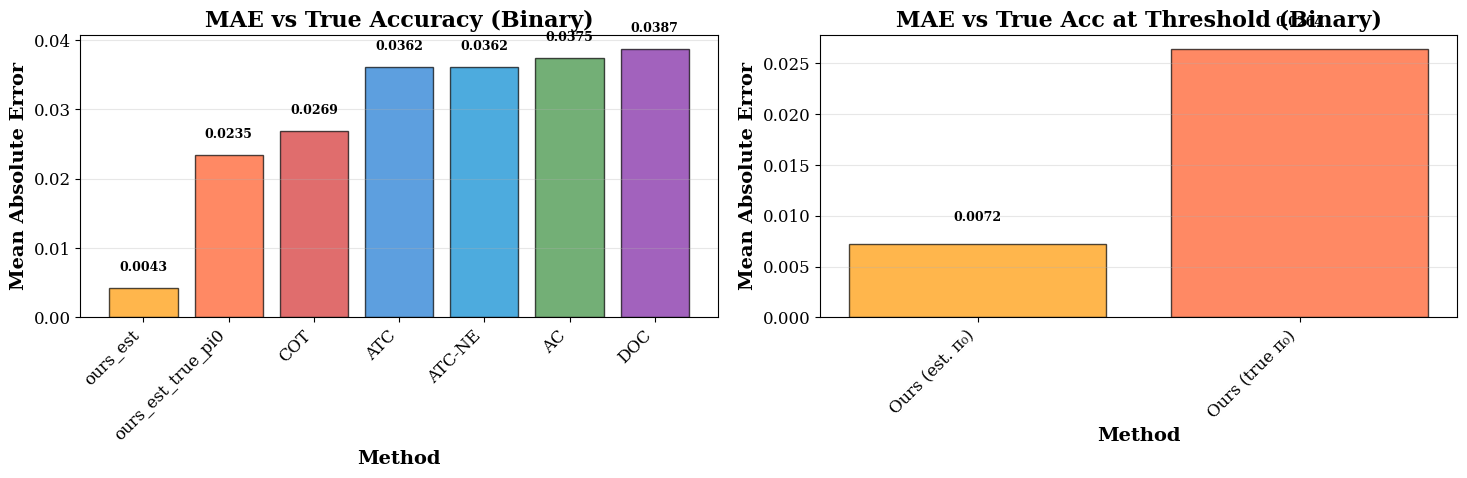

✓ Saved: mean_error_comparison_binary


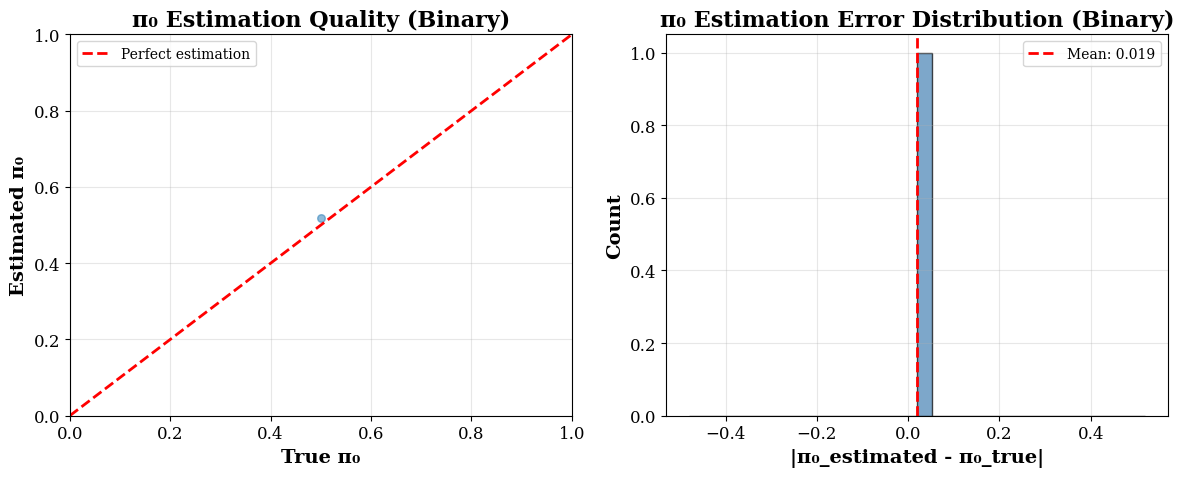

✓ Saved: pi0_diagnostics_binary


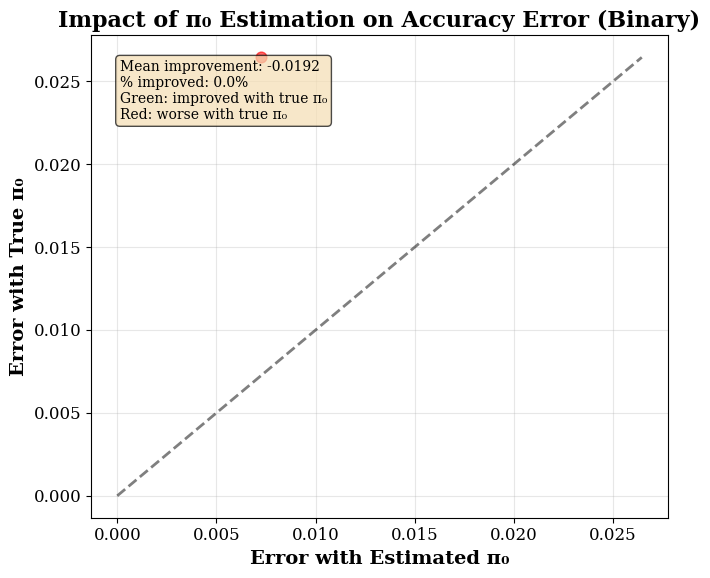

✓ Saved: pi0_impact_on_accuracy_binary

ANALYSIS COMPLETE (BINARY)
✓ Results saved to: figures/results_binary.csv

SUMMARY STATISTICS (BINARY)

1. Accuracy Statistics:
   Mean true accuracy: 0.8882 ± nan
   Mean best accuracy: 0.8911 ± nan
   Mean true accuracy at threshold: 0.8911 ± nan

2. π₀ Estimation:
   Mean estimated π₀: 0.5192 ± nan
   Mean true π₀: 0.5000 ± nan
   Mean |error|: 0.0192

3. Our Method Performance:
   With estimated π₀:
      MAE vs true_acc: 0.0043
      MAE vs true_acc@threshold: 0.0072
   With true π₀:
      MAE vs true_acc: 0.0235
      MAE vs true_acc@threshold: 0.0264

4. Baseline Results:
   ATC: MAE = 0.0362, estimated = 0.9243
   ATC-NE: MAE = 0.0362, estimated = 0.9243
   AC: MAE = 0.0375, estimated = 0.9256
   DOC: MAE = 0.0387, estimated = 0.9269
   COT: MAE = 0.0269, estimated = 0.9150

5. Improvement with True π₀:
   Mean error reduction: -0.0192
   % improved: 0.0%
   % worse: 100.0%

✓ DONE


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, chi2, pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
from bisect import bisect
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, Tuple, Optional, List

# Print versions
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

np.set_printoptions(threshold=np.inf)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.titlesize': 18,
    'font.family': 'serif',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

os.makedirs('figures/accuracy', exist_ok=True)
os.makedirs('figures/fdr_curves', exist_ok=True)
os.makedirs('figures/mano', exist_ok=True)
os.makedirs('figures/comparison', exist_ok=True)

PATH = 'figures/'

print("✓ Setup complete")


# ============================================================================
# CORE FDR FUNCTIONS — EXACTLY AS IN ORIGINAL
# ============================================================================

def empirical_p_values(distribution, query):
    dist_len = len(distribution)
    query_len = len(query)
    p_values = np.zeros(query_len)
    sorted_dist = np.sort(distribution)
    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(sorted_dist, score)) / dist_len
    return p_values


def estimate_pi0_storey(p_values, lambda_range=np.arange(0.05, 0.95, 0.05)):
    pi0_estimates = []
    for lam in lambda_range:
        pi0_lam = np.mean(p_values > lam) / (1 - lam)
        pi0_estimates.append(pi0_lam)
    pi0 = np.mean(pi0_estimates)
    return min(1.0, max(0, pi0))


def benjamini_hochberg_storey(p_values):
    n = len(p_values)
    pi0 = estimate_pi0_storey(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value
    return q_values


def benjamini_hochberg_fixed(p_values, pi0=1.0):
    n = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    q_values = np.zeros(n)
    prev_min = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        q_value = pi0 * sorted_p[i] * n / rank
        q_value = min(q_value, prev_min)
        q_values[sorted_indices[i]] = q_value
        prev_min = q_value
    return q_values


def benjamini_hochberg(p_values, pi0=1.0):
    """Alias for consistency."""
    return benjamini_hochberg_fixed(p_values, pi0=pi0)


def negative_training_benchmark(train_cnn_scores, train_labels, test_cnn_scores,
                                target_class, fdr_level=0.05):
    neg_train_mask = (train_labels != target_class)
    null_distribution = train_cnn_scores[neg_train_mask]
    test_scores = test_cnn_scores
    p_values = empirical_p_values(null_distribution, test_scores)
    q_values = benjamini_hochberg_storey(np.sort(p_values))
    n_discoveries = (q_values <= fdr_level).sum()
    return n_discoveries, q_values, p_values


# ============================================================================
# BINARY FDR CONTROL — PRESERVING ORIGINAL LOGIC EXACTLY
# ============================================================================

def control_fdr_binary(model_scores, target_labels, decoys,
                       train_cnn_scores=None, train_labels=None,
                       test_cnn_scores=None, target_class=None):
    """
    Binary FDR control — same logic as original control_fdr.
    
    Ground truth FDR uses label==0 as "false" (null hypothesis),
    label==1 as "true" (alternative), exactly as in the original code.
    """
    # Create dataframe with original index preserved
    df = pd.DataFrame({
        'model_score': model_scores,
        'label': target_labels,
        'decoy_score': decoys,
        'original_index': np.arange(len(model_scores))
    })
    
    # Compute p-values first (before any sorting)
    df['p_value'] = empirical_p_values(np.sort(decoys), model_scores)
    
    # Compute q-values using BH (before any sorting)
    df['q_values_bh_storey'] = benjamini_hochberg_storey(df['p_value'].values)
    df['q_values_bh_fixed'] = benjamini_hochberg_fixed(df['p_value'].values)
    
    # Now sort by model_score for ground truth FDR calculation
    df = df.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    
    # Ground truth FDR — EXACTLY AS ORIGINAL
    # label==0 means null (negative), label==1 means alternative (positive)
    df['fdr'] = 0.0
    num_neg = 0
    num_pos = 0
    
    for index, row in df.iterrows():
        if row['label'] == 0:
            num_neg += 1
        else:
            num_pos += 1
        if num_pos + num_neg > 0:
            df.at[index, 'fdr'] = (num_neg + 1.0) / (num_pos + num_neg)
    
    df['q_values_ground_truth'] = df['fdr'].copy()
    prev = 1
    for index in range(len(df) - 1, -1, -1):
        df.loc[index, 'q_values_ground_truth'] = min(prev, df.loc[index, 'q_values_ground_truth'])
        prev = df.loc[index, 'q_values_ground_truth']
    
    # TDC method — EXACTLY AS ORIGINAL
    df['max_score'] = df[['model_score', 'decoy_score']].max(axis=1)
    
    df_sorted_by_max = df.sort_values(by='max_score', ascending=False).reset_index(drop=True)
    
    fdr_tdc_list = []
    num_decoy_wins = 0
    num_target_wins = 0
    
    for index, row in df_sorted_by_max.iterrows():
        if row['model_score'] >= row['decoy_score']:  # Target wins
            num_target_wins += 1
            if num_target_wins > 0:
                fdr_tdc_list.append((num_decoy_wins + 1.0) / num_target_wins)
            else:
                fdr_tdc_list.append(1.0)
        else:  # Decoy wins
            num_decoy_wins += 1
            fdr_tdc_list.append(np.nan)
    
    df_sorted_by_max['fdr_tdc'] = fdr_tdc_list
    
    # Make monotone
    q_values_tdc_list = df_sorted_by_max['fdr_tdc'].tolist()
    prev = 1.0
    for index in range(len(q_values_tdc_list) - 1, -1, -1):
        if not np.isnan(q_values_tdc_list[index]):
            q_values_tdc_list[index] = min(prev, q_values_tdc_list[index])
            prev = q_values_tdc_list[index]
    
    df_sorted_by_max['q_values_tdc'] = q_values_tdc_list
    
    # Map TDC q-values back using original_index
    tdc_mapping = dict(zip(df_sorted_by_max['original_index'],
                           df_sorted_by_max['q_values_tdc']))
    df['q_values_tdc'] = df['original_index'].map(tdc_mapping)
    
    # Negative training — EXACTLY AS ORIGINAL
    if (train_cnn_scores is not None and train_labels is not None and
        test_cnn_scores is not None and target_class is not None):
        neg_train_mask = (train_labels != target_class)
        null_distribution = train_cnn_scores[neg_train_mask]
        
        p_values_neg_full = empirical_p_values(null_distribution, model_scores)
        q_values_neg_full = benjamini_hochberg_storey(p_values_neg_full)
        
        neg_p_mapping = dict(zip(np.arange(len(model_scores)), p_values_neg_full))
        neg_q_mapping = dict(zip(np.arange(len(model_scores)), q_values_neg_full))
        
        df['p_values_negative_training'] = df['original_index'].map(neg_p_mapping)
        df['q_values_negative_training'] = df['original_index'].map(neg_q_mapping)
    
    return df


# ============================================================================
# PLOTTING: FDR CURVES — EXACTLY AS ORIGINAL
# ============================================================================

def plot_fdr_comprehensive(df, filename="fdr_comprehensive"):
    """Comprehensive FDR plot with all methods"""
    plt.figure(figsize=(6, 4))
    
    methods = [
        ('q_values_tdc', 'TDC', 'blue', '-'),
        ('q_values_ground_truth', 'Ground Truth', 'green', '-'),
        ('q_values_bh_storey', 'BH (Storey π₀)', 'red', '-'),
    ]
    if 'q_values_negative_training' in df.columns:
        methods.append(('q_values_negative_training', 'Negative Training', 'orange', ':'))
    
    for col_name, label, color, linestyle in methods:
        df_sorted = df.sort_values(by=col_name, ascending=True).reset_index(drop=True)
        plt.plot(df_sorted[col_name], np.arange(len(df_sorted)),
                 marker='none', linestyle=linestyle, label=label, linewidth=2, color=color)
    
    plt.ylabel('Number of Discoveries')
    plt.xlabel('Q-values')
    plt.title('Comparison of FDR Control Methods')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, 1)
    
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()
    
    return plt


# ============================================================================
# CONFUSION MATRIX ESTIMATION — USING ORIGINAL FDR LOGIC
# ============================================================================

def estimate_confusion_matrix_v2(df, pi0):
    """
    Estimate confusion matrix using q-values.
    Uses label==0 as negative, label==1 as positive (same as original FDR).
    """
    df_cm = df.copy()
    total_samples = len(df)
    
    df_cm = df_cm.sort_values(by='model_score', ascending=False).reset_index(drop=True)
    df_cm['threshold'] = df_cm['model_score']
    df_cm['n_discoveries'] = np.arange(1, len(df_cm) + 1)
    
    # q-value IS the FDR estimate for making n_discoveries
    # FP = n_discoveries * q_value (false positives = label==0 samples among discoveries)
    df_cm['FP_est'] = df_cm['n_discoveries'] * df_cm['q_values_bh_storey']
    df_cm['TP_est'] = df_cm['n_discoveries'] - df_cm['FP_est']
    
    # For TN and FN, we need pi0
    df_cm['TN_est'] = total_samples * pi0 - df_cm['FP_est']
    df_cm['FN_est'] = total_samples * (1 - pi0) - df_cm['TP_est']
    
    df_cm['FP_est'] = np.maximum(0, df_cm['FP_est'])
    df_cm['TP_est'] = np.maximum(0, df_cm['TP_est'])
    df_cm['TN_est'] = np.maximum(0, df_cm['TN_est'])
    df_cm['FN_est'] = np.maximum(0, df_cm['FN_est'])
    
    df_cm['Accuracy_est'] = np.clip(
        (df_cm['TP_est'] + df_cm['TN_est']) / total_samples, 0.0, 1.0
    )
    
    # Ground truth — label==1 is positive, label==0 is negative
    df_cm['TP_true'] = (df_cm['label'] == 1).cumsum()
    df_cm['FP_true'] = (df_cm['label'] == 0).cumsum()
    df_cm['TN_true'] = (df_cm['label'] == 0).sum() - df_cm['FP_true']
    df_cm['FN_true'] = (df_cm['label'] == 1).sum() - df_cm['TP_true']
    df_cm['Accuracy_true'] = (df_cm['TP_true'] + df_cm['TN_true']) / total_samples
    
    return df_cm


def plot_confusion_matrix_analysis(df, pi0, filename="confusion_matrix_analysis"):
    """3-panel confusion matrix plot."""
    df_cm = estimate_confusion_matrix_v2(df, pi0)

    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 10,
        'figure.titlesize': 18
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(df_cm['threshold'], df_cm['TP_est'],
                 label='TP (estimated)', color='green', linewidth=2)
    axes[0].plot(df_cm['threshold'], df_cm['FP_est'],
                 label='FP (estimated)', color='red', linewidth=2)
    axes[0].plot(df_cm['threshold'], df_cm['TP_true'],
                 label='TP (true)', color='green', linewidth=1, linestyle='--', alpha=0.7)
    axes[0].set_xlabel('Threshold (score)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('True Positives and False Positives')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_cm['threshold'], df_cm['TN_est'],
                 label='TN (estimated)', color='blue', linewidth=2)
    axes[1].plot(df_cm['threshold'], df_cm['FN_est'],
                 label='FN (estimated)', color='orange', linewidth=2)
    axes[1].plot(df_cm['threshold'], df_cm['TN_true'],
                 label='TN (true)', color='blue', linewidth=1, linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Threshold (score)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('True Negatives and False Negatives')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df_cm['threshold'], df_cm['Accuracy_est'],
                 label='Accuracy (estimated)', color='dodgerblue', linewidth=2)
    axes[2].plot(df_cm['threshold'], df_cm['Accuracy_true'],
                 label='Accuracy (ground truth)', color='black', linewidth=2, linestyle='--')
    axes[2].set_xlabel('Threshold (score)')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Accuracy Estimation')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(PATH + filename + ".png", bbox_inches='tight', dpi=300)
    plt.savefig(PATH + filename + ".pdf", bbox_inches='tight')
    plt.show()

    return df_cm


def plot_fp_fn_accuracy_comparison(df, pi0, filename="fp_fn_accuracy_comparison"):
    """Single plot with FP/FN on left axis, accuracy on right axis."""
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 10,
        'figure.titlesize': 18
    })

    df_cm = estimate_confusion_matrix_v2(df, pi0)

    fig, ax1 = plt.subplots(figsize=(6, 4), constrained_layout=True)

    line_fp_est, = ax1.plot(df_cm['threshold'], df_cm['FP_est'],
                            color='red', linewidth=2, label='FP (est)')
    line_fp_true, = ax1.plot(df_cm['threshold'], df_cm['FP_true'],
                             color='red', linestyle='--', linewidth=1, alpha=0.7, label='FP (true)')
    line_fn_est, = ax1.plot(df_cm['threshold'], df_cm['FN_est'],
                            color='orange', linewidth=2, label='FN (est)')
    line_fn_true, = ax1.plot(df_cm['threshold'], df_cm['FN_true'],
                             color='orange', linestyle='--', linewidth=1, alpha=0.7, label='FN (true)')

    ax1.set_xlabel('Threshold (score)')
    ax1.set_ylabel('FP / FN count')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    line_acc_est, = ax2.plot(df_cm['threshold'], df_cm['Accuracy_est'],
                             color='dodgerblue', linewidth=2, label='Accuracy (est)')
    line_acc_true, = ax2.plot(df_cm['threshold'], df_cm['Accuracy_true'],
                              color='black', linestyle='--', linewidth=2, label='Accuracy (true)')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)

    ax1.legend(handles=[line_fp_est, line_fp_true, line_fn_est, line_fn_true],
               loc='lower left', frameon=True)
    ax2.legend(handles=[line_acc_est, line_acc_true],
               loc='lower right', frameon=True)

    ax1.set_title('FP/FN and Accuracy vs Threshold')

    plt.savefig(PATH + filename + ".png", dpi=300)
    plt.savefig(PATH + filename + ".pdf")
    plt.show()

    return df_cm


# ============================================================================
# BASELINE METHODS FOR BINARY
# ============================================================================

def _to_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).float()
    return x.float()


def binary_confidence(logits):
    """Confidence for binary: max(P(y=1), P(y=0))."""
    if logits.dim() > 1 and logits.shape[1] == 1:
        logits = logits.squeeze(1)
    prob_pos = torch.sigmoid(logits)
    confidence = torch.maximum(prob_pos, 1 - prob_pos)
    return confidence


def binary_predictions(logits):
    """Binary predictions from logits."""
    if logits.dim() > 1 and logits.shape[1] == 1:
        logits = logits.squeeze(1)
    return (logits > 0).long()


def negentropy_binary(logits):
    """Negentropy for binary."""
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits).float()
    if logits.dim() > 1 and logits.shape[1] == 1:
        logits = logits.squeeze(1)
    prob_pos = torch.sigmoid(logits)
    probs = torch.stack([1 - prob_pos, prob_pos], dim=1)
    entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
    max_entropy = np.log(2)
    return max_entropy - entropy


def calibration_temp_binary(logits, labels):
    """Find optimal temperature for binary calibration."""
    if isinstance(logits, np.ndarray):
        logits = torch.tensor(logits).float()
    if isinstance(labels, np.ndarray):
        labels = torch.tensor(labels).long()
    if logits.dim() > 1 and logits.shape[1] == 1:
        logits = logits.squeeze(1)

    temps = np.linspace(0.5, 3.0, 100)
    best_temp = 1.0
    best_nll = float('inf')

    for temp in temps:
        prob_pos = torch.sigmoid(logits / temp)
        nll = -torch.mean(
            labels.float() * torch.log(prob_pos + 1e-8) +
            (1 - labels.float()) * torch.log(1 - prob_pos + 1e-8)
        ).item()
        if nll < best_nll:
            best_nll = nll
            best_temp = temp

    return best_temp


def predict_ATC_maxconf_binary(source_logits, source_labels, target_logits):
    """ATC with max confidence for binary."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)

    if source_logits.dim() > 1 and source_logits.shape[1] == 1:
        source_logits = source_logits.squeeze(1)
    if target_logits.dim() > 1 and target_logits.shape[1] == 1:
        target_logits = target_logits.squeeze(1)

    source_scores = binary_confidence(source_logits)
    target_scores = binary_confidence(target_logits)

    source_preds = binary_predictions(source_logits)
    source_correct = (source_preds == source_labels)

    sorted_source_scores, _ = torch.sort(source_scores)
    n_correct = source_correct.sum()
    if n_correct == 0 or n_correct >= len(source_scores):
        threshold = 0.5
    else:
        threshold = sorted_source_scores[-n_correct].item()

    estimate = (target_scores > threshold).float().mean().item()
    return np.clip(estimate, 0.0, 1.0)


def predict_ATC_negent_binary(source_logits, source_labels, target_logits):
    """ATC with negentropy for binary."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)

    if source_logits.dim() > 1 and source_logits.shape[1] == 1:
        source_logits = source_logits.squeeze(1)
    if target_logits.dim() > 1 and target_logits.shape[1] == 1:
        target_logits = target_logits.squeeze(1)

    source_scores = negentropy_binary(source_logits)
    target_scores = negentropy_binary(target_logits)

    source_preds = binary_predictions(source_logits)
    source_correct = (source_preds == source_labels)

    sorted_source_scores, _ = torch.sort(source_scores)
    n_correct = source_correct.sum()
    if n_correct == 0 or n_correct >= len(source_scores):
        threshold = 0.0
    else:
        threshold = sorted_source_scores[-n_correct].item()

    estimate = (target_scores > threshold).float().mean().item()
    return np.clip(estimate, 0.0, 1.0)


def predict_AC_binary(source_logits, source_labels, target_logits):
    """Average Confidence for binary."""
    target_logits = _to_tensor(target_logits)
    if target_logits.dim() > 1 and target_logits.shape[1] == 1:
        target_logits = target_logits.squeeze(1)
    conf = binary_confidence(target_logits)
    return np.clip(conf.mean().item(), 0.0, 1.0)


def predict_DOC_binary(source_logits, source_labels, target_logits):
    """Difference of Confidences for binary."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)

    if source_logits.dim() > 1 and source_logits.shape[1] == 1:
        source_logits = source_logits.squeeze(1)
    if target_logits.dim() > 1 and target_logits.shape[1] == 1:
        target_logits = target_logits.squeeze(1)

    avg_source_conf = binary_confidence(source_logits).mean().item()
    avg_target_conf = binary_confidence(target_logits).mean().item()

    source_preds = binary_predictions(source_logits)
    source_acc = (source_preds == source_labels).float().mean().item()

    estimate = source_acc + (avg_target_conf - avg_source_conf)
    return np.clip(estimate, 0.0, 1.0)


try:
    import ot

    def predict_COT_binary(source_logits, source_labels, target_logits):
        """COT for binary classification."""
        source_logits = _to_tensor(source_logits)
        source_labels = _to_tensor(source_labels).long()
        target_logits = _to_tensor(target_logits)

        if source_logits.dim() > 1 and source_logits.shape[1] == 1:
            source_logits = source_logits.squeeze(1)
        if target_logits.dim() > 1 and target_logits.shape[1] == 1:
            target_logits = target_logits.squeeze(1)

        source_prob_pos = torch.sigmoid(source_logits)
        source_probs = torch.stack([1 - source_prob_pos, source_prob_pos], dim=1)

        target_prob_pos = torch.sigmoid(target_logits)
        target_probs = torch.stack([1 - target_prob_pos, target_prob_pos], dim=1)

        source_label_dist = torch.nn.functional.one_hot(
            source_labels, 2
        ).float().mean(0)

        eye = torch.eye(2, device=target_logits.device)
        cost_matrix = torch.cdist(target_probs, eye, p=1) / 2

        n_target = target_probs.shape[0]
        target_dist = np.ones(n_target) / n_target
        source_dist = source_label_dist.cpu().numpy()

        target_dist = target_dist / target_dist.sum()
        source_dist = source_dist / source_dist.sum()

        cost_matrix_np = cost_matrix.detach().cpu().numpy()

        ot_plan = ot.emd(target_dist, source_dist, cost_matrix_np)
        ot_cost = np.sum(ot_plan * cost_matrix_np)

        s_conf = binary_confidence(source_logits).mean().item()
        source_preds = binary_predictions(source_logits)
        s_acc = (source_preds == source_labels).float().mean().item()
        conf_gap = s_conf - s_acc

        err_est = ot_cost + conf_gap
        estimate = 1. - err_est

        return float(np.clip(estimate, 0.0, 1.0))

    COT_AVAILABLE = True
    print("✓ COT available")
except ImportError:
    COT_AVAILABLE = False
    print("⚠ COT unavailable (install: pip install POT)")

BASELINE_METHODS = {
    'ATC': predict_ATC_maxconf_binary,
    'ATC-NE': predict_ATC_negent_binary,
    'AC': predict_AC_binary,
    'DOC': predict_DOC_binary,
}
if COT_AVAILABLE:
    BASELINE_METHODS['COT'] = predict_COT_binary

print(f"✓ Baseline methods (binary): {list(BASELINE_METHODS.keys())}")


# ============================================================================
# HELPER FUNCTIONS FOR ACCURACY ESTIMATION
# ============================================================================

def compute_true_pi0_binary(model_scores, labels):
    """True π₀ = proportion of label==0 (negatives)."""
    return (labels == 0).mean()


def compute_method_estimation_curve_binary(df, q_value_column, pi0):
    """
    Compute estimation curve for binary FDR.
    Here: TP = label==1, FP = label==0 among discoveries.
    """
    total_samples = len(df)
    df_method = df[~df[q_value_column].isna()].copy()

    if len(df_method) == 0:
        return pd.DataFrame()

    df_method = df_method.sort_values(by=q_value_column, ascending=True).reset_index(drop=True)
    df_method['n_discoveries'] = np.arange(1, len(df_method) + 1)

    # Estimated from q-values
    df_method['FP_est'] = df_method['n_discoveries'] * df_method[q_value_column]
    df_method['TP_est'] = df_method['n_discoveries'] - df_method['FP_est']
    df_method['TN_est'] = total_samples * pi0 - df_method['FP_est']
    df_method['FN_est'] = total_samples * (1 - pi0) - df_method['TP_est']

    df_method['FP_est'] = np.maximum(0, df_method['FP_est'])
    df_method['TP_est'] = np.maximum(0, df_method['TP_est'])
    df_method['TN_est'] = np.maximum(0, df_method['TN_est'])
    df_method['FN_est'] = np.maximum(0, df_method['FN_est'])

    df_method['Accuracy_est'] = np.clip(
        (df_method['TP_est'] + df_method['TN_est']) / total_samples, 0.0, 1.0
    )

    # True metrics: label==1 is positive, label==0 is negative
    df_method['TP_true'] = (df_method['label'] == 1).cumsum()
    df_method['FP_true'] = (df_method['label'] == 0).cumsum()
    total_neg = (df_method['label'] == 0).sum()
    total_pos = (df_method['label'] == 1).sum()
    df_method['TN_true'] = total_neg - df_method['FP_true']
    df_method['FN_true'] = total_pos - df_method['TP_true']
    df_method['Accuracy_true'] = (df_method['TP_true'] + df_method['TN_true']) / total_samples

    return df_method[[q_value_column, 'Accuracy_est', 'Accuracy_true',
                      'FP_est', 'TP_est', 'FN_est', 'TN_est',
                      'FP_true', 'TP_true', 'FN_true', 'TN_true']].rename(
        columns={q_value_column: 'q_value_method'})


def compute_best_gt_accuracy_binary(model_scores, labels):
    """
    Oracle: best possible accuracy by thresholding score for binary.
    Here accuracy = (TP + TN) / total where TP = label==1 with score >= threshold,
    TN = label==0 with score < threshold.
    """
    order = np.argsort(-model_scores)
    labels_sorted = labels[order]
    scores_sorted = model_scores[order]

    n = len(labels)
    total_pos = (labels == 1).sum()
    total_neg = (labels == 0).sum()

    # TP = cumulative label==1 above threshold
    tp = np.cumsum(labels_sorted == 1)
    fp = np.cumsum(labels_sorted == 0)
    tn = total_neg - fp
    fn = total_pos - tp

    acc = (tp + tn) / n

    best_idx = acc.argmax()
    best_acc = acc[best_idx]
    best_threshold = scores_sorted[best_idx]
    best_n_accepted = best_idx + 1

    return best_acc, best_threshold, best_n_accepted


def compute_accuracy_at_threshold_binary(model_scores, labels, threshold):
    """Compute accuracy when accepting samples with score >= threshold."""
    accepted_mask = model_scores >= threshold
    n_accepted = accepted_mask.sum()

    if n_accepted == 0:
        return 0.0, 0

    total_pos = (labels == 1).sum()
    total_neg = (labels == 0).sum()

    tp = ((labels == 1) & accepted_mask).sum()
    tn = ((labels == 0) & (~accepted_mask)).sum()

    acc = (tp + tn) / len(labels)

    return acc, n_accepted


def estimate_pi0_storey_from_df(df):
    """Estimate π₀ from DataFrame (LABEL-FREE)."""
    if 'p_value' in df.columns:
        p_values = df['p_value'].dropna().values
        if len(p_values) > 0:
            return estimate_pi0_storey(p_values)
    return 0.5


print("✓ All helper functions loaded")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

# -----------------------------------------------------------------------
# !!! DEFINE THESE BEFORE RUNNING !!!
# scores_flow_train : 1D numpy array of training target scores
# decoys_flow_train : 1D numpy array of training decoy scores  
# labels_flow_train : 1D numpy array of training labels (0 or 1)
# scores_flow       : 1D numpy array of test target scores
# decoys_flow       : 1D numpy array of test decoy scores
# labels_flow       : 1D numpy array of test labels (0 or 1)
# -----------------------------------------------------------------------

# Ensure 1D
if hasattr(scores_flow, 'ndim') and scores_flow.ndim > 1:
    scores_flow = scores_flow.flatten()
if hasattr(decoys_flow, 'ndim') and decoys_flow.ndim > 1:
    decoys_flow = decoys_flow.flatten()
if hasattr(scores_flow_train, 'ndim') and scores_flow_train.ndim > 1:
    scores_flow_train = scores_flow_train.flatten()
if hasattr(decoys_flow_train, 'ndim') and decoys_flow_train.ndim > 1:
    decoys_flow_train = decoys_flow_train.flatten()

print(f"Test scores shape: {scores_flow.shape}")
print(f"Test decoys shape: {decoys_flow.shape}")
print(f"Test labels shape: {labels_flow.shape}")
print(f"Train scores shape: {scores_flow_train.shape}")

try:
    corruption_name
except NameError:
    corruption_name = "binary_test"


# ============================================================================
# Step 1: Binary FDR Control — SAME AS ORIGINAL
# ============================================================================

print("\n" + "=" * 80)
print("STEP 1: Binary FDR Control")
print("=" * 80)

df_flow = control_fdr_binary(scores_flow, labels_flow, decoys_flow,
                              scores_flow_train.flatten(), labels_flow_train,
                              scores_flow, target_class=1)

print(f"DataFrame shape: {df_flow.shape}")
print(f"Columns: {list(df_flow.columns)}")

# ============================================================================
# Step 2: Monotonicity Check — SAME AS ORIGINAL
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: Monotonicity and Diagnostics")
print("=" * 80)

print("P-values monotone check:", np.all(np.diff(df_flow['p_value']) >= -1e-10))
print("Q-values monotone check:", np.all(np.diff(df_flow['q_values_bh_storey']) >= -1e-10))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(df_flow['model_score'].values, df_flow['p_value'].values)
plt.xlabel('Model Score (sorted descending)')
plt.ylabel('P-value')
plt.title('P-value vs Model Score')

plt.subplot(1, 3, 2)
plt.plot(df_flow['model_score'].values, df_flow['q_values_bh_storey'].values)
plt.xlabel('Model Score (sorted descending)')
plt.ylabel('Q-value BH')
plt.title('Q-value vs Model Score')

plt.subplot(1, 3, 3)
plt.scatter(range(len(df_flow)), df_flow['q_values_bh_storey'].values, s=1)
plt.xlabel('Rank (by model_score)')
plt.ylabel('Q-value BH')
plt.title('Q-values should be monotone')
plt.tight_layout()
plt.savefig(PATH + "diagnostics_binary.png", dpi=300)
plt.show()

# ============================================================================
# Step 3: FDR Curves
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: FDR Curves")
print("=" * 80)

plot_fdr_comprehensive(df_flow, filename="fdr_comprehensive_binary")

# ============================================================================
# Step 4: Confusion Matrix Analysis
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: Confusion Matrix Analysis")
print("=" * 80)

p_values = empirical_p_values(np.sort(decoys_flow), scores_flow)
pi0_estimated = estimate_pi0_storey(p_values)
pi0_true = compute_true_pi0_binary(scores_flow, labels_flow)

print(f"Estimated π₀: {pi0_estimated:.3f}")
print(f"True π₀ (proportion of label==0): {pi0_true:.3f}")
print(f"|π₀ error|: {abs(pi0_estimated - pi0_true):.3f}")

df_cm = plot_confusion_matrix_analysis(df_flow, pi0_estimated,
                                        filename="confusion_matrix_analysis_binary")

df_cm2 = plot_fp_fn_accuracy_comparison(df_flow, pi0_estimated,
                                         filename="fp_fn_accuracy_comparison_binary")


# ============================================================================
# Step 5: Comparison with Baselines
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: Comparison with Baselines")
print("=" * 80)

source_logits = scores_flow_train
source_labels = labels_flow_train

temp = calibration_temp_binary(source_logits, source_labels)
print(f'✓ Calibration temperature: {temp:.3f}')

results = []
pi0_diagnostics_all = []

model_scores_1d = scores_flow
decoy_scores_1d = decoys_flow
labels_np = labels_flow

# --- TRUE ACC (label==1 is positive, score > 0 means predict positive) ---
predicted = (model_scores_1d > 0).astype(int)
true_acc = (predicted == labels_np).mean()
print(f"True accuracy: {true_acc:.4f}")

# --- BEST (ORACLE) ---
best_acc, best_threshold, best_n_accepted = compute_best_gt_accuracy_binary(
    model_scores_1d, labels_np
)
print(f"Best (oracle) accuracy: {best_acc:.4f} at threshold {best_threshold:.4f}")

# --- TRUE ACCURACY AT BEST THRESHOLD ---
true_acc_at_threshold, n_accepted_check = compute_accuracy_at_threshold_binary(
    model_scores_1d, labels_np, best_threshold
)
print(f"True accuracy at best threshold: {true_acc_at_threshold:.4f}")

# --- OUR METHOD (BH with Storey π₀) ---
pi0_est = estimate_pi0_storey_from_df(df_flow)
df_method_est = compute_method_estimation_curve_binary(
    df_flow, 'q_values_bh_storey', pi0_est
)

est_acc_ours = df_method_est['Accuracy_est'].max() if len(df_method_est) > 0 else 0.0
print(f"Our method estimated accuracy (estimated π₀={pi0_est:.3f}): {est_acc_ours:.4f}")

# --- OUR METHOD WITH TRUE π₀ ---
df_method_true = compute_method_estimation_curve_binary(
    df_flow, 'q_values_bh_storey', pi0_true
)

est_acc_ours_true = df_method_true['Accuracy_est'].max() if len(df_method_true) > 0 else 0.0
print(f"Our method estimated accuracy (true π₀={pi0_true:.3f}): {est_acc_ours_true:.4f}")

pi0_diagnostics_all.append({
    'corruption': corruption_name,
    'pi0_estimated': [pi0_est],
    'pi0_true': [pi0_true],
    'pi0_error': [abs(pi0_est - pi0_true)]
})

# --- BASELINES ---
target_logits_tensor = torch.tensor(model_scores_1d).float().to(DEVICE)
source_logits_tensor = torch.tensor(source_logits).float().to(DEVICE)
source_labels_tensor = torch.tensor(source_labels).long().to(DEVICE)

scaled_source = source_logits_tensor / temp
scaled_target = target_logits_tensor / temp

baseline_results = {}
for method_name, method_func in BASELINE_METHODS.items():
    try:
        estimate = method_func(scaled_source, source_labels_tensor, scaled_target)
        baseline_results[method_name] = estimate
        print(f"  {method_name}: {estimate:.4f}")
    except Exception as e:
        print(f"  {method_name}: FAILED ({e})")
        baseline_results[method_name] = np.nan

results.append({
    'corruption': corruption_name,
    'true_acc': true_acc,
    'best_acc': best_acc,
    'true_acc_at_threshold': true_acc_at_threshold,
    'best_threshold': best_threshold,
    'best_n_accepted': best_n_accepted,
    'ours_est': est_acc_ours,
    'ours_est_true_pi0': est_acc_ours_true,
    'pi0_estimated': pi0_est,
    'pi0_true': pi0_true,
    **baseline_results
})

print(f"\n✓ Processed {len(results)} dataset(s)")

# ============================================================================
# CREATE DATAFRAME
# ============================================================================

results_df = pd.DataFrame(results)

# ============================================================================
# π₀ DIAGNOSTICS
# ============================================================================

print("\n" + "=" * 80)
print("π₀ ESTIMATION DIAGNOSTICS")
print("=" * 80)

all_pi0_estimated = []
all_pi0_true = []
all_pi0_errors = []

for diag in pi0_diagnostics_all:
    for est, true, err in zip(diag['pi0_estimated'], diag['pi0_true'], diag['pi0_error']):
        if not np.isnan(est) and not np.isnan(true):
            all_pi0_estimated.append(est)
            all_pi0_true.append(true)
            all_pi0_errors.append(err)

all_pi0_estimated = np.array(all_pi0_estimated)
all_pi0_true = np.array(all_pi0_true)
all_pi0_errors = np.array(all_pi0_errors)

print(f"\nOverall π₀ Statistics:")
if len(all_pi0_estimated) > 0:
    print(f"  Mean π₀ estimated: {all_pi0_estimated.mean():.3f} ± {all_pi0_estimated.std():.3f}")
    print(f"  Mean π₀ true:      {all_pi0_true.mean():.3f} ± {all_pi0_true.std():.3f}")
    print(f"  Mean π₀ error:     {all_pi0_errors.mean():.3f} ± {all_pi0_errors.std():.3f}")

# ============================================================================
# ANALYSIS AND PLOTTING
# ============================================================================

print("\n" + "=" * 80)
print("COMPUTING ERRORS")
print("=" * 80)

results_df['error_at_threshold_est'] = np.abs(
    results_df['ours_est'] - results_df['true_acc_at_threshold']
)
results_df['error_at_threshold_true_pi0'] = np.abs(
    results_df['ours_est_true_pi0'] - results_df['true_acc_at_threshold']
)

methods = ['ours_est', 'ours_est_true_pi0', 'ATC', 'ATC-NE', 'AC', 'DOC']
if 'COT' in results_df.columns:
    methods.append('COT')

print("\nMean Absolute Error (MAE) vs True Accuracy:")
print("-" * 60)
for method in methods:
    if method in results_df.columns:
        errors = np.abs(results_df[method] - results_df['true_acc'])
        mae = errors.mean()
        std = errors.std()
        print(f"{method:25s}: {mae:.4f} ± {std:.4f}")

print("\nMean Absolute Error (MAE) vs True Accuracy at Threshold:")
print("-" * 60)
print(f"{'ours_est (estimated π₀)':25s}: {results_df['error_at_threshold_est'].mean():.4f} ± {results_df['error_at_threshold_est'].std():.4f}")
print(f"{'ours_est (true π₀)':25s}: {results_df['error_at_threshold_true_pi0'].mean():.4f} ± {results_df['error_at_threshold_true_pi0'].std():.4f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 80)
print("CREATING VISUALIZATIONS")
print("=" * 80)

colors_map = {
    'ours_est': '#FF9800',
    'ours_est_true_pi0': '#FF5722',
    'ATC': '#1976D2',
    'ATC-NE': '#0288D1',
    'AC': '#388E3C',
    'DOC': '#7B1FA2',
    'COT': '#D32F2F'
}

# Plot 1: True vs Best Accuracy
plt.figure(figsize=(6, 6))
plt.scatter(results_df['true_acc'], results_df['best_acc'], alpha=0.7, s=50, label='Best (oracle)')
plt.scatter(results_df['true_acc'], results_df['true_acc_at_threshold'],
            alpha=0.7, s=50, color='green', label='At best threshold')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Accuracy (all predictions)', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('True vs Best/Threshold Accuracy (Binary)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/scatter_true_vs_best_binary.png', dpi=300)
plt.savefig('figures/scatter_true_vs_best_binary.pdf')
plt.show()
print("✓ Saved: scatter_true_vs_best_binary")

# Plot 2: Comparison scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for method in methods:
    if method in results_df.columns:
        axes[0].scatter(
            results_df['true_acc'],
            results_df[method],
            label=method,
            alpha=0.6, s=50,
            color=colors_map.get(method, 'gray')
        )

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect')
axes[0].set_xlabel('True Accuracy', fontweight='bold')
axes[0].set_ylabel('Estimated Accuracy', fontweight='bold')
axes[0].set_title('Estimated vs True Accuracy (Binary)', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[1].scatter(
    results_df['true_acc_at_threshold'],
    results_df['ours_est'],
    label='Ours (estimated π₀)',
    alpha=0.6, s=50, color=colors_map['ours_est']
)
axes[1].scatter(
    results_df['true_acc_at_threshold'],
    results_df['ours_est_true_pi0'],
    label='Ours (true π₀)',
    alpha=0.6, s=50, color=colors_map['ours_est_true_pi0']
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect')
axes[1].set_xlabel('True Accuracy at Threshold', fontweight='bold')
axes[1].set_ylabel('Estimated Accuracy', fontweight='bold')
axes[1].set_title('Estimated vs True Acc at Threshold (Binary)', fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/scatter_est_vs_true_comparison_binary.png', dpi=300)
plt.savefig('figures/scatter_est_vs_true_comparison_binary.pdf')
plt.show()
print("✓ Saved: scatter_est_vs_true_comparison_binary")

# Plot 3: MAE bar chart
mae_data = []
for method in methods:
    if method in results_df.columns:
        errors = np.abs(results_df[method] - results_df['true_acc'])
        mae = errors.mean()
        mae_data.append({'Method': method, 'Error Type': 'vs true_acc', 'MAE': mae})

mae_data.append({
    'Method': 'ours_est',
    'Error Type': 'vs true_acc@threshold',
    'MAE': results_df['error_at_threshold_est'].mean()
})
mae_data.append({
    'Method': 'ours_est_true_pi0',
    'Error Type': 'vs true_acc@threshold',
    'MAE': results_df['error_at_threshold_true_pi0'].mean()
})

mae_df = pd.DataFrame(mae_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mae_df_true_acc = mae_df[mae_df['Error Type'] == 'vs true_acc'].sort_values('MAE')
colors_list = [colors_map.get(m, 'gray') for m in mae_df_true_acc['Method']]
axes[0].bar(range(len(mae_df_true_acc)), mae_df_true_acc['MAE'],
            color=colors_list, alpha=0.7, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Method', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[0].set_title('MAE vs True Accuracy (Binary)', fontweight='bold')
axes[0].set_xticks(range(len(mae_df_true_acc)))
axes[0].set_xticklabels(mae_df_true_acc['Method'], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(mae_df_true_acc.iterrows()):
    axes[0].text(i, row['MAE'] + 0.002, f"{row['MAE']:.4f}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

mae_df_threshold = mae_df[mae_df['Error Type'] == 'vs true_acc@threshold']
colors_list2 = [colors_map.get(m, 'gray') for m in mae_df_threshold['Method']]
axes[1].bar(range(len(mae_df_threshold)), mae_df_threshold['MAE'],
            color=colors_list2, alpha=0.7, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Method', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[1].set_title('MAE vs True Acc at Threshold (Binary)', fontweight='bold')
axes[1].set_xticks(range(len(mae_df_threshold)))
axes[1].set_xticklabels(['Ours (est. π₀)', 'Ours (true π₀)'], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(mae_df_threshold.iterrows()):
    axes[1].text(i, row['MAE'] + 0.002, f"{row['MAE']:.4f}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/mean_error_comparison_binary.png', dpi=300)
plt.savefig('figures/mean_error_comparison_binary.pdf')
plt.show()
print("✓ Saved: mean_error_comparison_binary")

# Plot 4: π₀ diagnostics
if len(all_pi0_estimated) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(all_pi0_true, all_pi0_estimated, alpha=0.5, s=30)
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect estimation')
    axes[0].set_xlabel('True π₀', fontweight='bold')
    axes[0].set_ylabel('Estimated π₀', fontweight='bold')
    axes[0].set_title('π₀ Estimation Quality (Binary)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

    axes[1].hist(all_pi0_errors, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].axvline(np.mean(all_pi0_errors), color='red', linestyle='--',
                    linewidth=2, label=f'Mean: {np.mean(all_pi0_errors):.3f}')
    axes[1].set_xlabel('|π₀_estimated - π₀_true|', fontweight='bold')
    axes[1].set_ylabel('Count', fontweight='bold')
    axes[1].set_title('π₀ Estimation Error Distribution (Binary)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/pi0_diagnostics_binary.png', dpi=300)
    plt.savefig('figures/pi0_diagnostics_binary.pdf')
    plt.show()
    print("✓ Saved: pi0_diagnostics_binary")

# Plot 5: π₀ impact
fig, ax = plt.subplots(figsize=(7, 6))

improvement = results_df['error_at_threshold_est'] - results_df['error_at_threshold_true_pi0']
colors_imp = ['green' if x > 0 else 'red' for x in improvement]

ax.scatter(results_df['error_at_threshold_est'],
           results_df['error_at_threshold_true_pi0'],
           c=colors_imp, alpha=0.6, s=60)

max_val = max(results_df['error_at_threshold_est'].max(),
              results_df['error_at_threshold_true_pi0'].max())
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, alpha=0.5, label='Equal error')

ax.set_xlabel('Error with Estimated π₀', fontweight='bold')
ax.set_ylabel('Error with True π₀', fontweight='bold')
ax.set_title('Impact of π₀ Estimation on Accuracy Error (Binary)', fontweight='bold')
ax.grid(True, alpha=0.3)

mean_improvement = improvement.mean()
pct_improved = (improvement > 0).mean() * 100
ax.text(0.05, 0.95,
        f"Mean improvement: {mean_improvement:.4f}\n"
        f"% improved: {pct_improved:.1f}%\n"
        f"Green: improved with true π₀\n"
        f"Red: worse with true π₀",
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=10)

plt.tight_layout()
plt.savefig('figures/pi0_impact_on_accuracy_binary.png', dpi=300)
plt.savefig('figures/pi0_impact_on_accuracy_binary.pdf')
plt.show()
print("✓ Saved: pi0_impact_on_accuracy_binary")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE (BINARY)")
print("=" * 80)

results_df.to_csv('figures/results_binary.csv', index=False)
print(f"✓ Results saved to: figures/results_binary.csv")

print("\n" + "=" * 80)
print("SUMMARY STATISTICS (BINARY)")
print("=" * 80)

print(f"\n1. Accuracy Statistics:")
print(f"   Mean true accuracy: {results_df['true_acc'].mean():.4f} ± {results_df['true_acc'].std():.4f}")
print(f"   Mean best accuracy: {results_df['best_acc'].mean():.4f} ± {results_df['best_acc'].std():.4f}")
print(f"   Mean true accuracy at threshold: {results_df['true_acc_at_threshold'].mean():.4f} ± {results_df['true_acc_at_threshold'].std():.4f}")

print(f"\n2. π₀ Estimation:")
print(f"   Mean estimated π₀: {results_df['pi0_estimated'].mean():.4f} ± {results_df['pi0_estimated'].std():.4f}")
print(f"   Mean true π₀: {results_df['pi0_true'].mean():.4f} ± {results_df['pi0_true'].std():.4f}")
print(f"   Mean |error|: {np.abs(results_df['pi0_estimated'] - results_df['pi0_true']).mean():.4f}")

print(f"\n3. Our Method Performance:")
print(f"   With estimated π₀:")
print(f"      MAE vs true_acc: {np.abs(results_df['ours_est'] - results_df['true_acc']).mean():.4f}")
print(f"      MAE vs true_acc@threshold: {results_df['error_at_threshold_est'].mean():.4f}")
print(f"   With true π₀:")
print(f"      MAE vs true_acc: {np.abs(results_df['ours_est_true_pi0'] - results_df['true_acc']).mean():.4f}")
print(f"      MAE vs true_acc@threshold: {results_df['error_at_threshold_true_pi0'].mean():.4f}")

print(f"\n4. Baseline Results:")
for method in ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']:
    if method in results_df.columns:
        mae = np.abs(results_df[method] - results_df['true_acc']).mean()
        print(f"   {method}: MAE = {mae:.4f}, estimated = {results_df[method].iloc[0]:.4f}")

print(f"\n5. Improvement with True π₀:")
improvement = results_df['error_at_threshold_est'] - results_df['error_at_threshold_true_pi0']
print(f"   Mean error reduction: {improvement.mean():.4f}")
print(f"   % improved: {(improvement > 0).mean() * 100:.1f}%")
print(f"   % worse: {(improvement < 0).mean() * 100:.1f}%")

print("\n✓ DONE")